# Visualization Analysis - Geographic Performance

## Purpose
This notebook visualizes geographic sales performance across regions, markets, and countries.  
The goal is to identify where sales and profit are concentrated, where margins are weak, and where geographic risk may affect business performance.

## Main questions
- Which regions and markets contribute most to sales and profit?
- Where are margins strongest or weakest geographically?
- Are returns or discount behavior concentrated in specific geographies?
- How dependent is the business on a small number of countries or markets?

## Contents
- [1. Executive Overview](#executive-overview)
- [2. Regional Performance Overview](#regional-performance-overview)
- [3. Market Breakdown within Regions](#market-breakdown-within-regions)
- [4. Country Performance within Markets](#country-performance-within-markets)
- [5. Geographic Risk and Volatility](#geographic-risk-and-volatility)
- [6. Concentration and Dependency Analysis](#concentration-and-dependency-analysis)
- [7. Geographic Map View](#geographic-map-view)

In [137]:
library(ggplot2)
library(scales)

theme_set(
    theme_minimal(base_size = 13) +
        theme(
          plot.title = element_text(size = 18, face = "bold"),
          plot.subtitle = element_text(size = 14),
          axis.title = element_text(size = 16),
          axis.text = element_text(size = 14),
          strip.text = element_text(size = 14, face = "bold"),
          legend.title = element_text(size = 16),
          legend.text = element_text(size = 14),
          panel.grid.minor = element_blank()
    )
)

geo_fill_main <- "#4C78A8"
geo_fill_alt  <- "#F58518"
geo_fill_risk <- "#E45756"
geo_fill_soft <- "#72B7B2"

In [138]:
# Load required libraries
library(tidyverse)
library(janitor)
library(dplyr)
library(skimr)
library(purrr)
library(maps)
library(lubridate)

# Source helper scripts
source("../../R/apply_factors.R")
source("../../R/analysis_helpers.R")
source("../../R/temporal_helpers.R")

# Load data
tables <- list(
  Orders  = readr::read_csv("../../data/processed/Orders.csv"),
  Returns = readr::read_csv("../../data/processed/Returns.csv"),
  People  = readr::read_csv("../../data/processed/People.csv")
)

# Apply factor transformations
tables <- apply_factors(tables)

# Extract tables
orders  <- tables$Orders
returns <- tables$Returns
people  <- tables$People

Rows: 51290 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (13): order_id, ship_mode, customer_name, segment, state, country, mark...
dbl   (6): sales, quantity, discount, profit, shipping_cost, year
date  (2): order_date, ship_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1173 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): order_id, market
lgl (1): returned

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 14 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): person, region

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the co

## Executive Overview

### Total Sales by Region

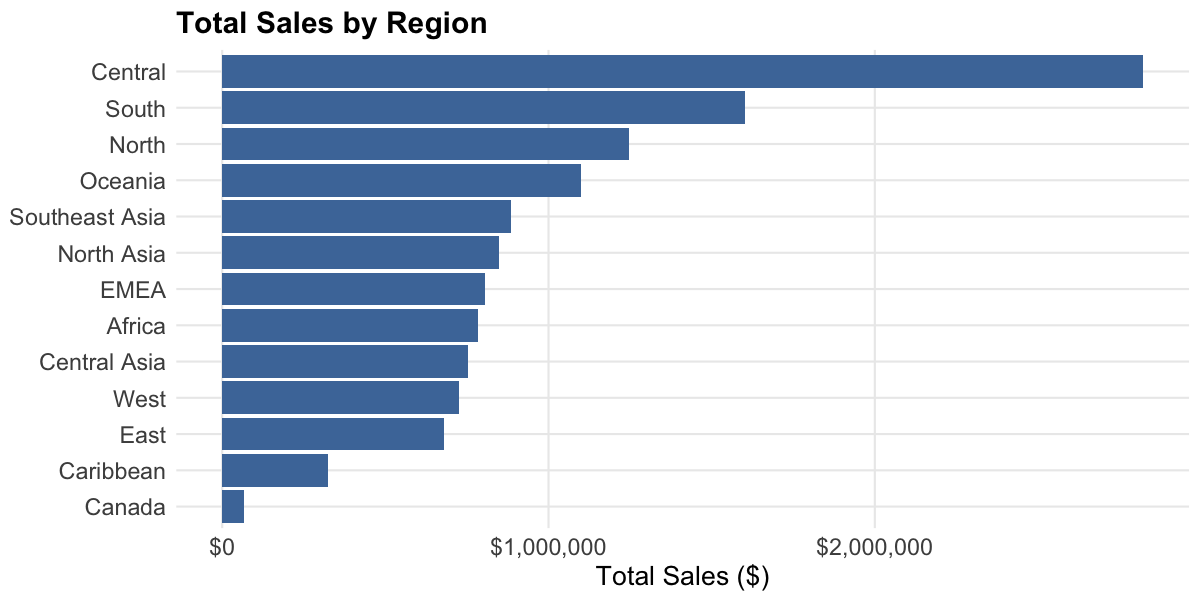

In [139]:
options(repr.plot.width = 10, repr.plot.height = 5)

region_sales <- orders |> 
    group_by(region) |> 
    summarise(
        total_sales = sum(sales),
        .groups = "drop"
    ) |> 
    arrange(desc(total_sales))

ggplot(region_sales, aes(x = reorder(region, total_sales), y = total_sales)) +
    geom_col(fill = geo_fill_main) +
    coord_flip() +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Total Sales by Region",
        x = NULL,
        y = "Total Sales ($)"
    ) 

### Total Profit by Region

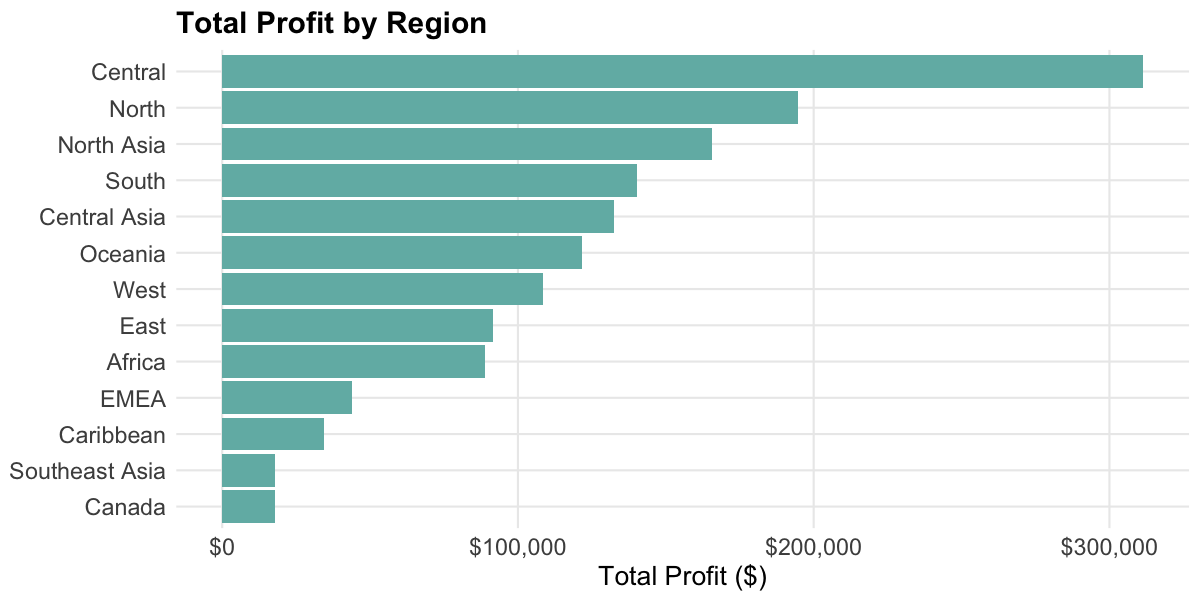

In [140]:
options(repr.plot.width = 10, repr.plot.height = 5)

region_profit <- orders |> 
    group_by(region) |> 
    summarise(
        total_profit = sum(profit),
        .groups = "drop"
    ) |> 
    arrange(desc(total_profit))

ggplot(region_profit, aes(x = reorder(region, total_profit), y = total_profit)) +
    geom_col(fill = geo_fill_soft) +
    coord_flip() +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Total Profit by Region",
        x = NULL,
        y = "Total Profit ($)"
    ) 

### Profit Margin by Region

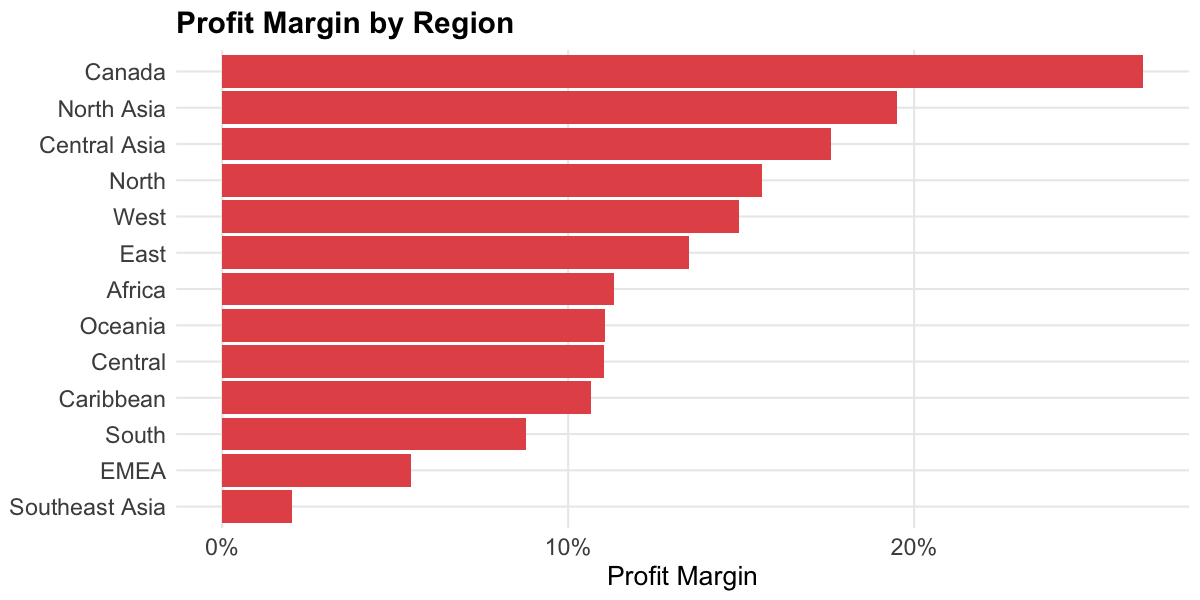

In [141]:
options(repr.plot.width = 10, repr.plot.height = 5)

region_margin <- orders |>
    group_by(region) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        profit_margin = total_profit / total_sales,
        .groups = "drop"
    ) |>
    arrange(desc(profit_margin))

ggplot(region_margin, aes(x = reorder(region, profit_margin), y = profit_margin)) +
    geom_col(fill = geo_fill_risk) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    labs(
        title = "Profit Margin by Region",
        x = NULL,
        y = "Profit Margin"
    ) 

# Regional Performance Overview

### Sales vs Profit by Region Scatterplot

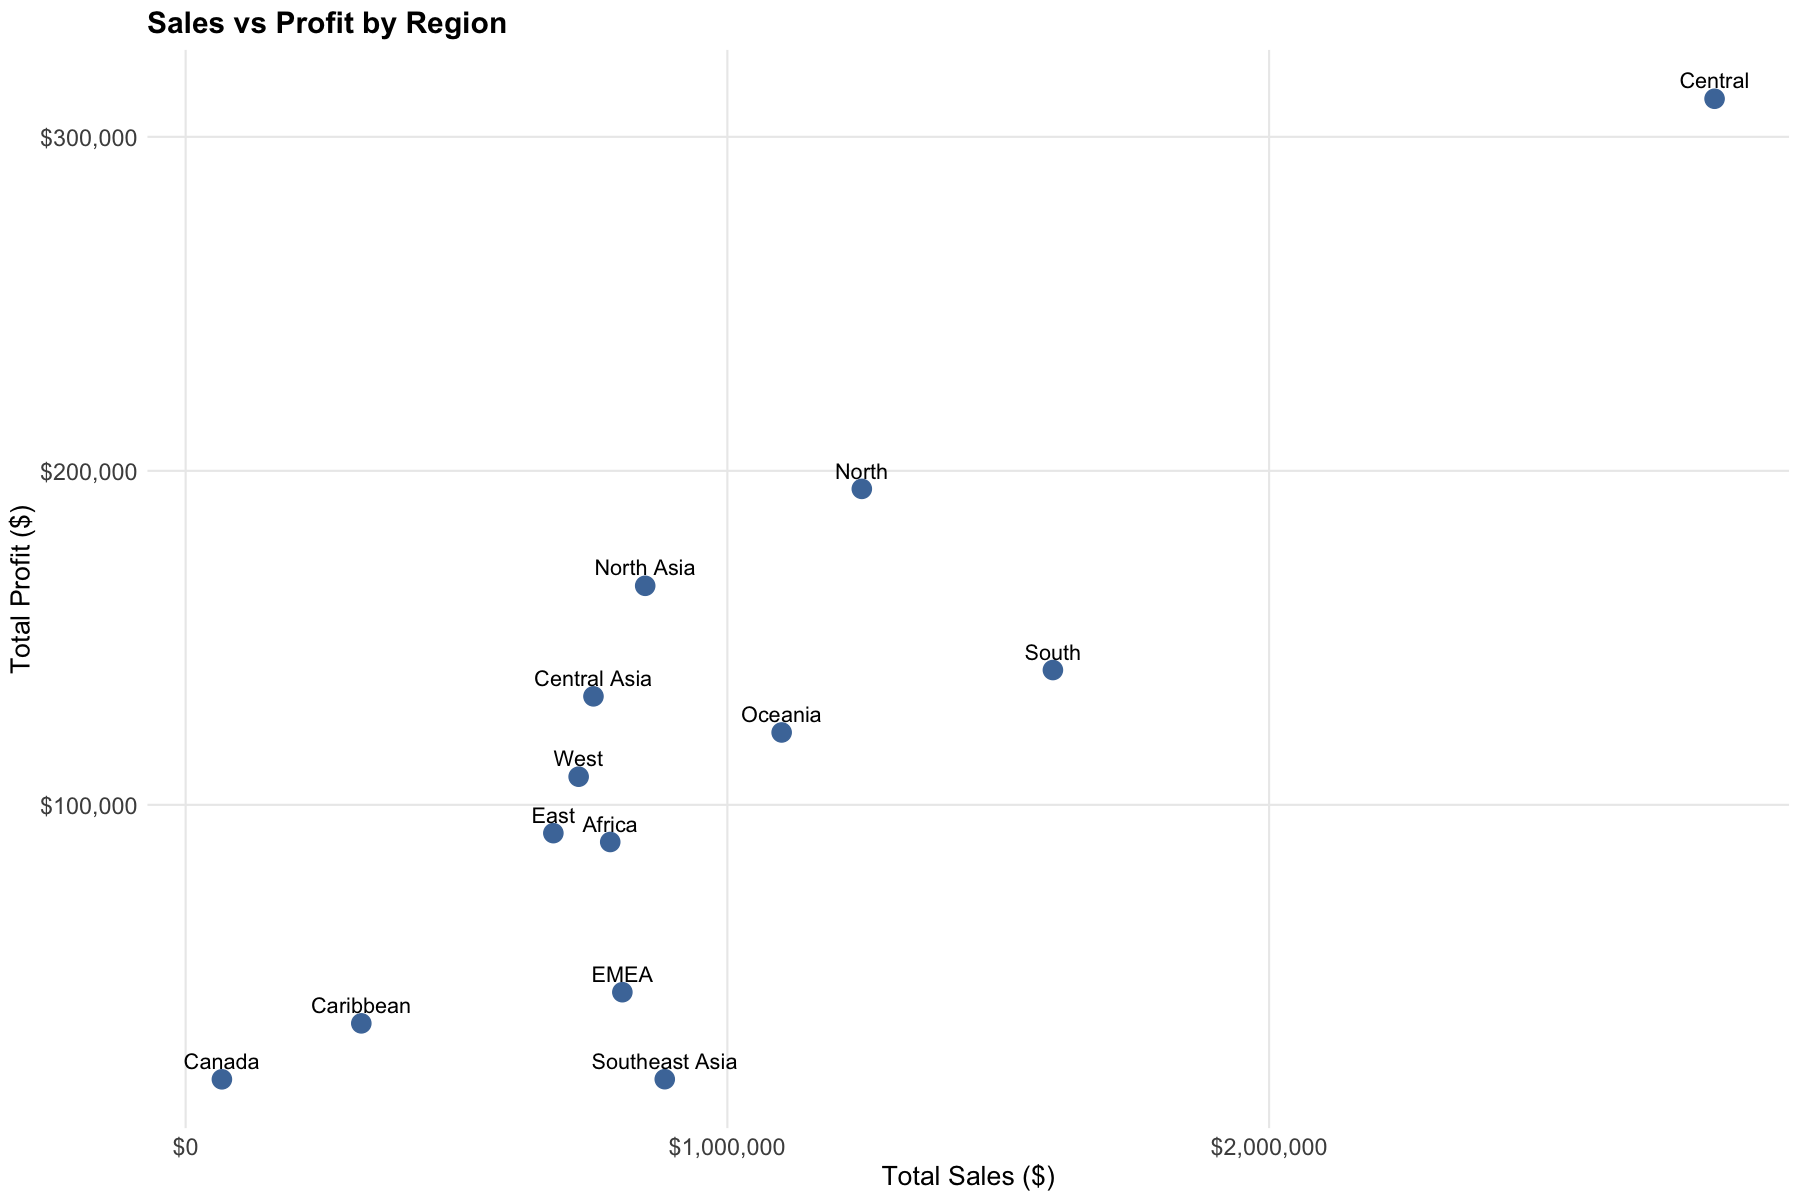

In [142]:
options(repr.plot.width = 15, repr.plot.height = 10)

region_scatter <- orders |>
    group_by(region) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        n_orders = n(),
        .groups = "drop"
    )

ggplot(region_scatter, aes(x = total_sales, y = total_profit, label = region)) +
    geom_point(size = 5, color = geo_fill_main) +
    geom_text(vjust = -0.7) +
    scale_x_continuous(labels = scales::dollar_format()) +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Sales vs Profit by Region",
        x = "Total Sales ($)",
        y = "Total Profit ($)"
    ) 

### Orders vs Sales by Region

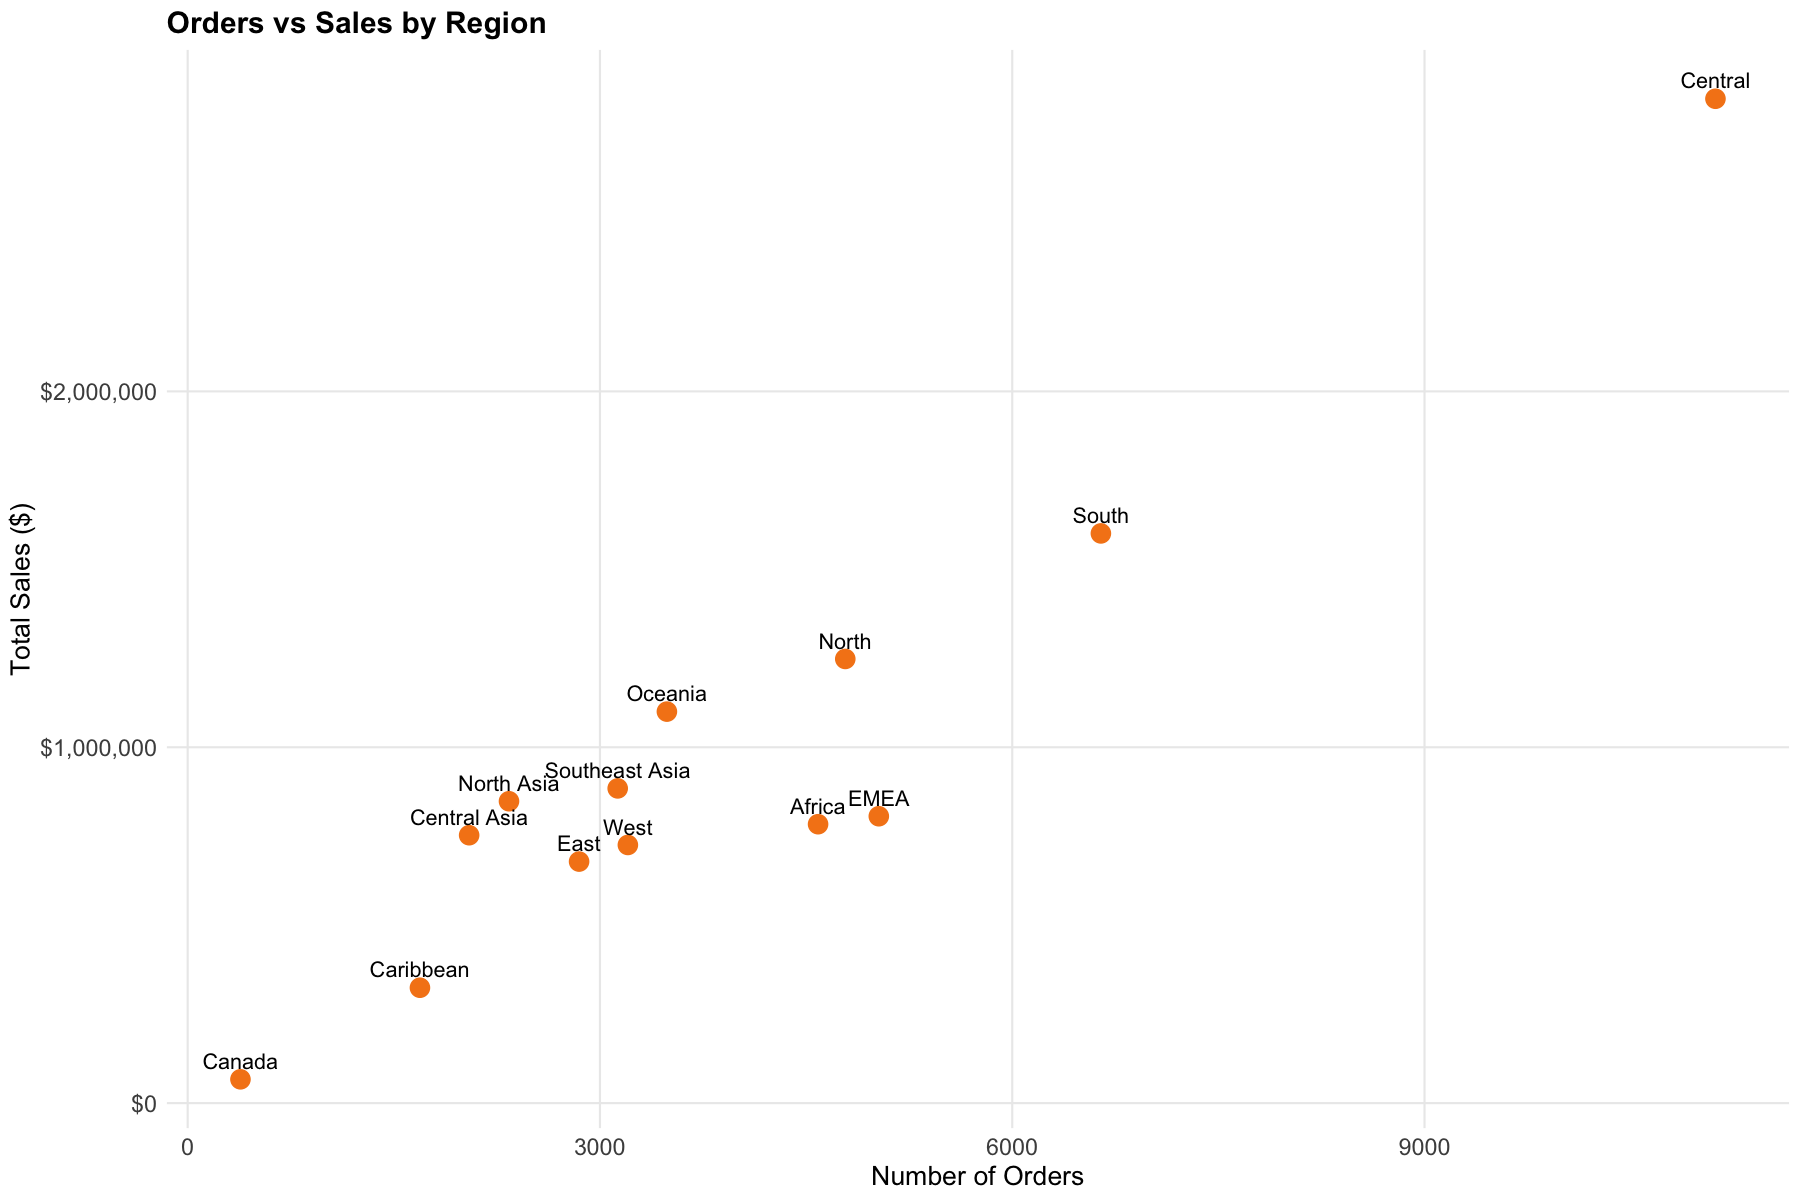

In [143]:
options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(region_scatter, aes(x = n_orders, y = total_sales, label = region)) +
    geom_point(size = 5, color = geo_fill_alt) +
    geom_text(vjust = -0.7) +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Orders vs Sales by Region",
        x = "Number of Orders",
        y = "Total Sales ($)"
    ) 

### Section Interpretation 

The regional comparison shows that geographic performance is uneven across the business. Some regions account for much larger shares of sales and profit, while others contribute less despite still generating a meaningful number of orders. The sales-versus-profit view is useful because it separates scale from efficiency: a region may be large in revenue terms but not proportionally strong in profitability. The profit margin comparison adds another layer by showing that high sales do not automatically translate into strong operational performance. From a business perspective, this section helps distinguish between **scale leaders** and **efficiency leaders**. Regions with high sales but weaker margins may require pricing, cost, or discount review, while regions with smaller sales but stronger margins may represent more sustainable growth opportunities.

## Market Breakdown within Regions

### Sales by Market

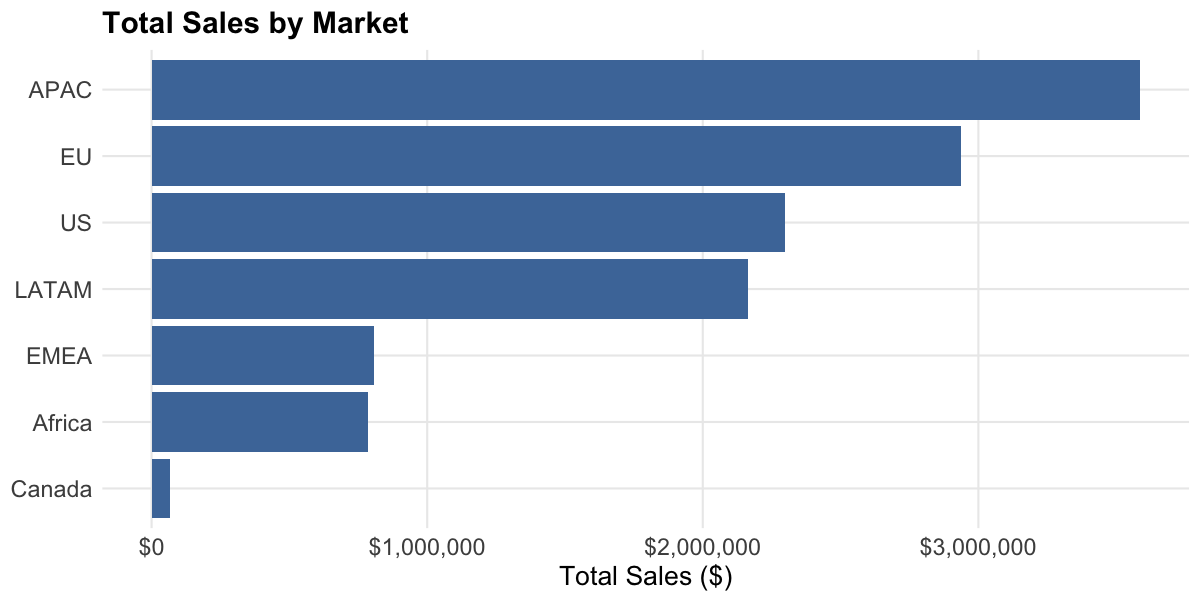

In [144]:
options(repr.plot.width = 10, repr.plot.height = 5)

market_sales <- orders |>
    group_by(market) |>
    summarise(
        total_sales = sum(sales, na.rm = TRUE),
        .groups = "drop"
    )

ggplot(
    market_sales,
    aes(x = reorder(market, total_sales), y = total_sales)
) +
    geom_col(fill = geo_fill_main) +
    coord_flip() +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Total Sales by Market",
        x = NULL,
        y = "Total Sales ($)"
    )

### Profit Margin by Market

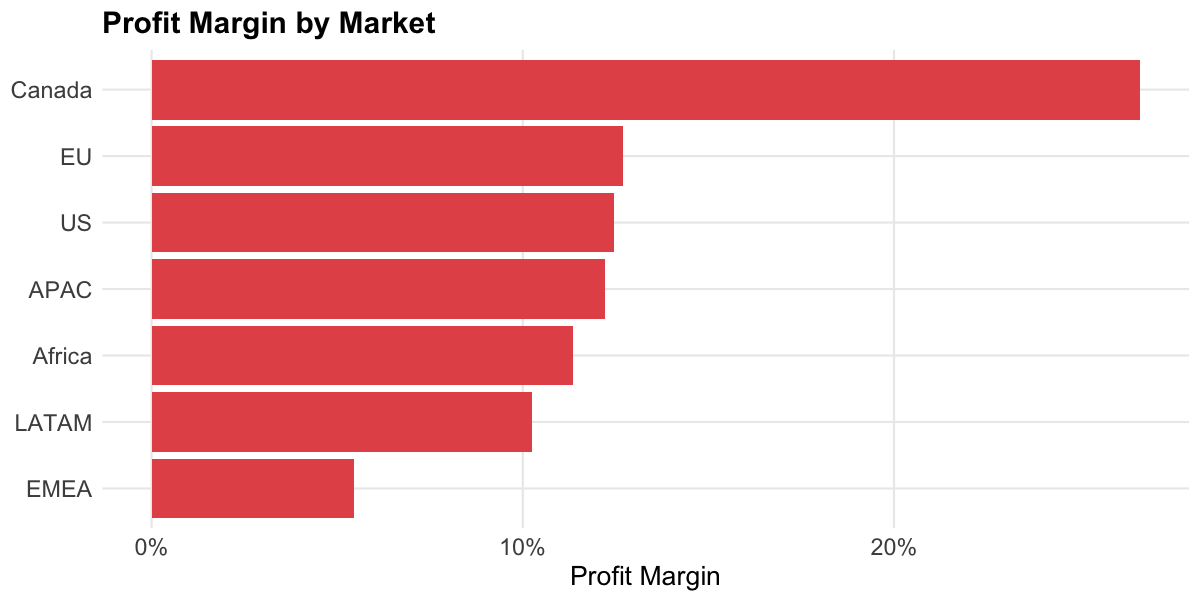

In [145]:
options(repr.plot.width = 10, repr.plot.height = 5)

market_margin <- orders |>
    group_by(market) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        profit_margin = total_profit / total_sales,
        .groups = "drop"
    )

ggplot(
    market_margin,
    aes(x = reorder(market, profit_margin), y = profit_margin)
) +
    geom_col(fill = geo_fill_risk) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    labs(
        title = "Profit Margin by Market",
        x = NULL,
        y = "Profit Margin"
    ) 

### Market share of global sales

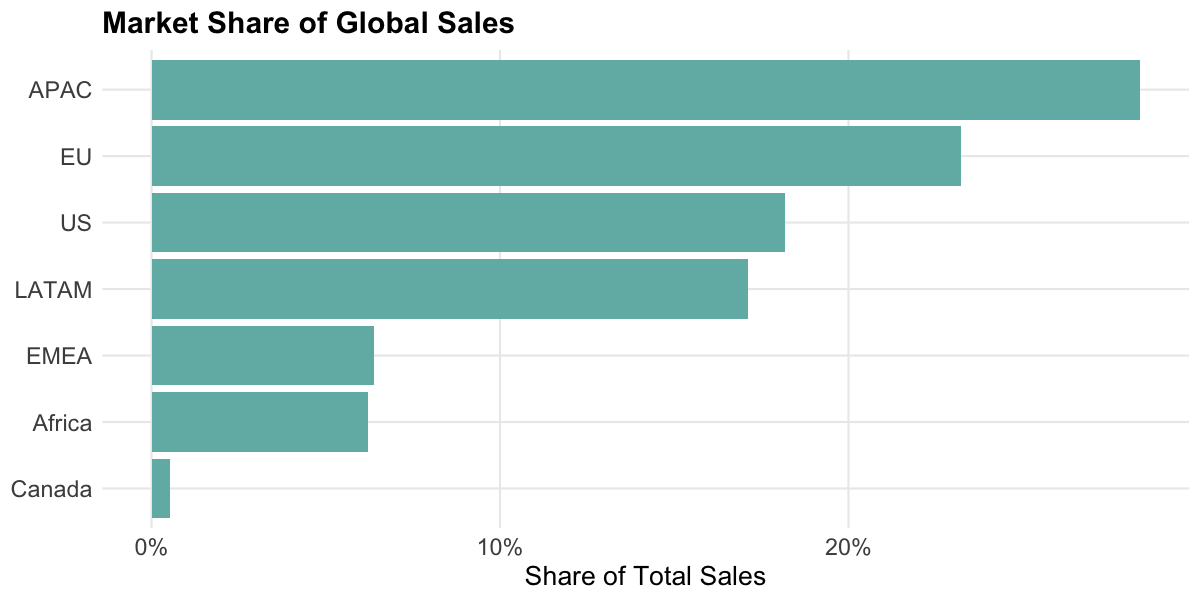

In [146]:
options(repr.plot.width = 10, repr.plot.height = 5)

market_sales <- orders |>
    group_by(market) |>
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        orders = n_distinct(order_id),
        profit_margin = total_profit / total_sales
    )

market_sales <- market_sales |>
    mutate(share = total_sales / sum(total_sales))

ggplot(
    market_sales,
    aes(x = reorder(market, share), y = share)
) +
    geom_col(fill = geo_fill_soft) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    labs(
        title = "Market Share of Global Sales",
        x = NULL,
        y = "Share of Total Sales"
    ) 

### Section Interpretation 

The market-level visuals show whether overall geographic performance is broad-based or concentrated in a few major markets. Sales totals identify the largest revenue contributors, while market share highlights dependency on specific geographic areas. Profit margin adds an efficiency lens, showing that not all large markets are equally attractive from a profitability standpoint.

## Country Performance within Markets

### Top/Bottom N Countries by Sales (per market)

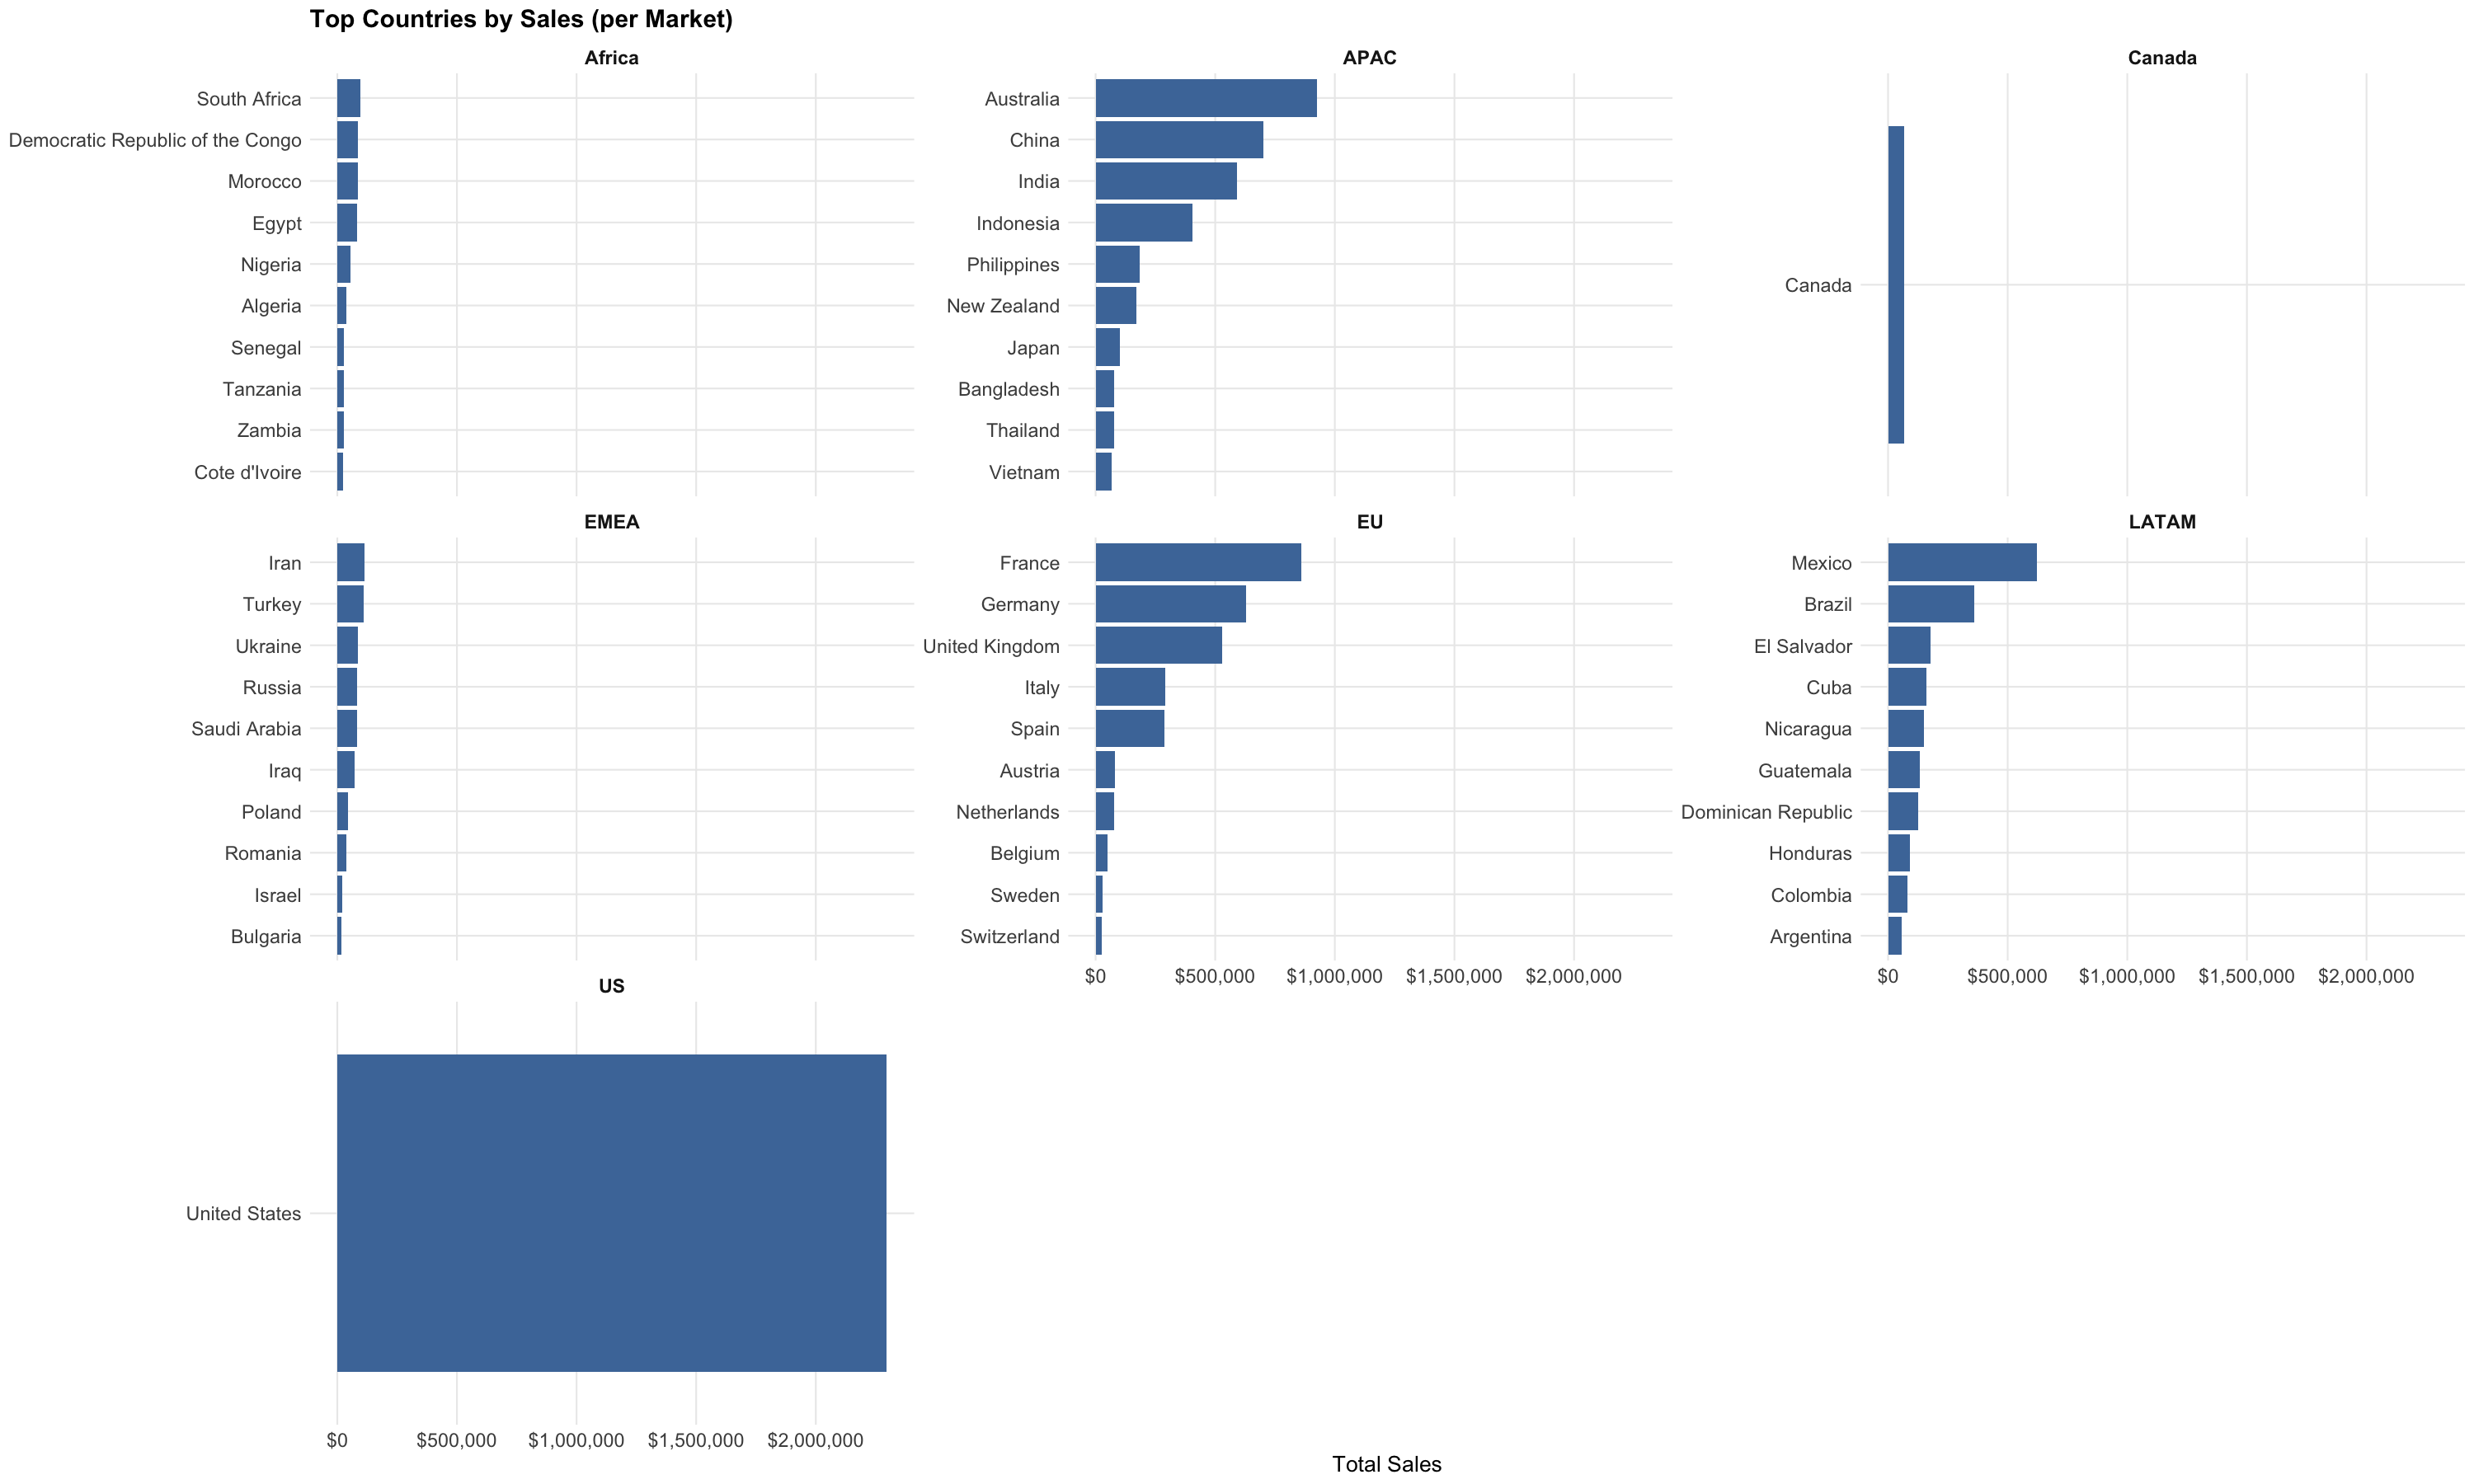

In [147]:
N <- 10

country_sales_market <- orders |> 
    group_by(market, country) |> 
    summarise(total_sales = sum(sales), .groups = "drop")

top_countries <- country_sales_market |> 
    group_by(market) |> 
    slice_max(total_sales, n = N) |> 
    ungroup()

bottom_countries <- country_sales_market |> 
    group_by(market) |> 
    slice_min(total_sales, n = N) |> 
    ungroup()

options(repr.plot.width = 25, repr.plot.height = 15)

ggplot(
    top_countries,
    aes(x = reorder(country, total_sales), y = total_sales)
) +
    geom_col(fill = geo_fill_main) +
    coord_flip() +
    facet_wrap(~market, scales = "free_y") +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Top Countries by Sales (per Market)",
        x = NULL,
        y = "Total Sales"
    ) 

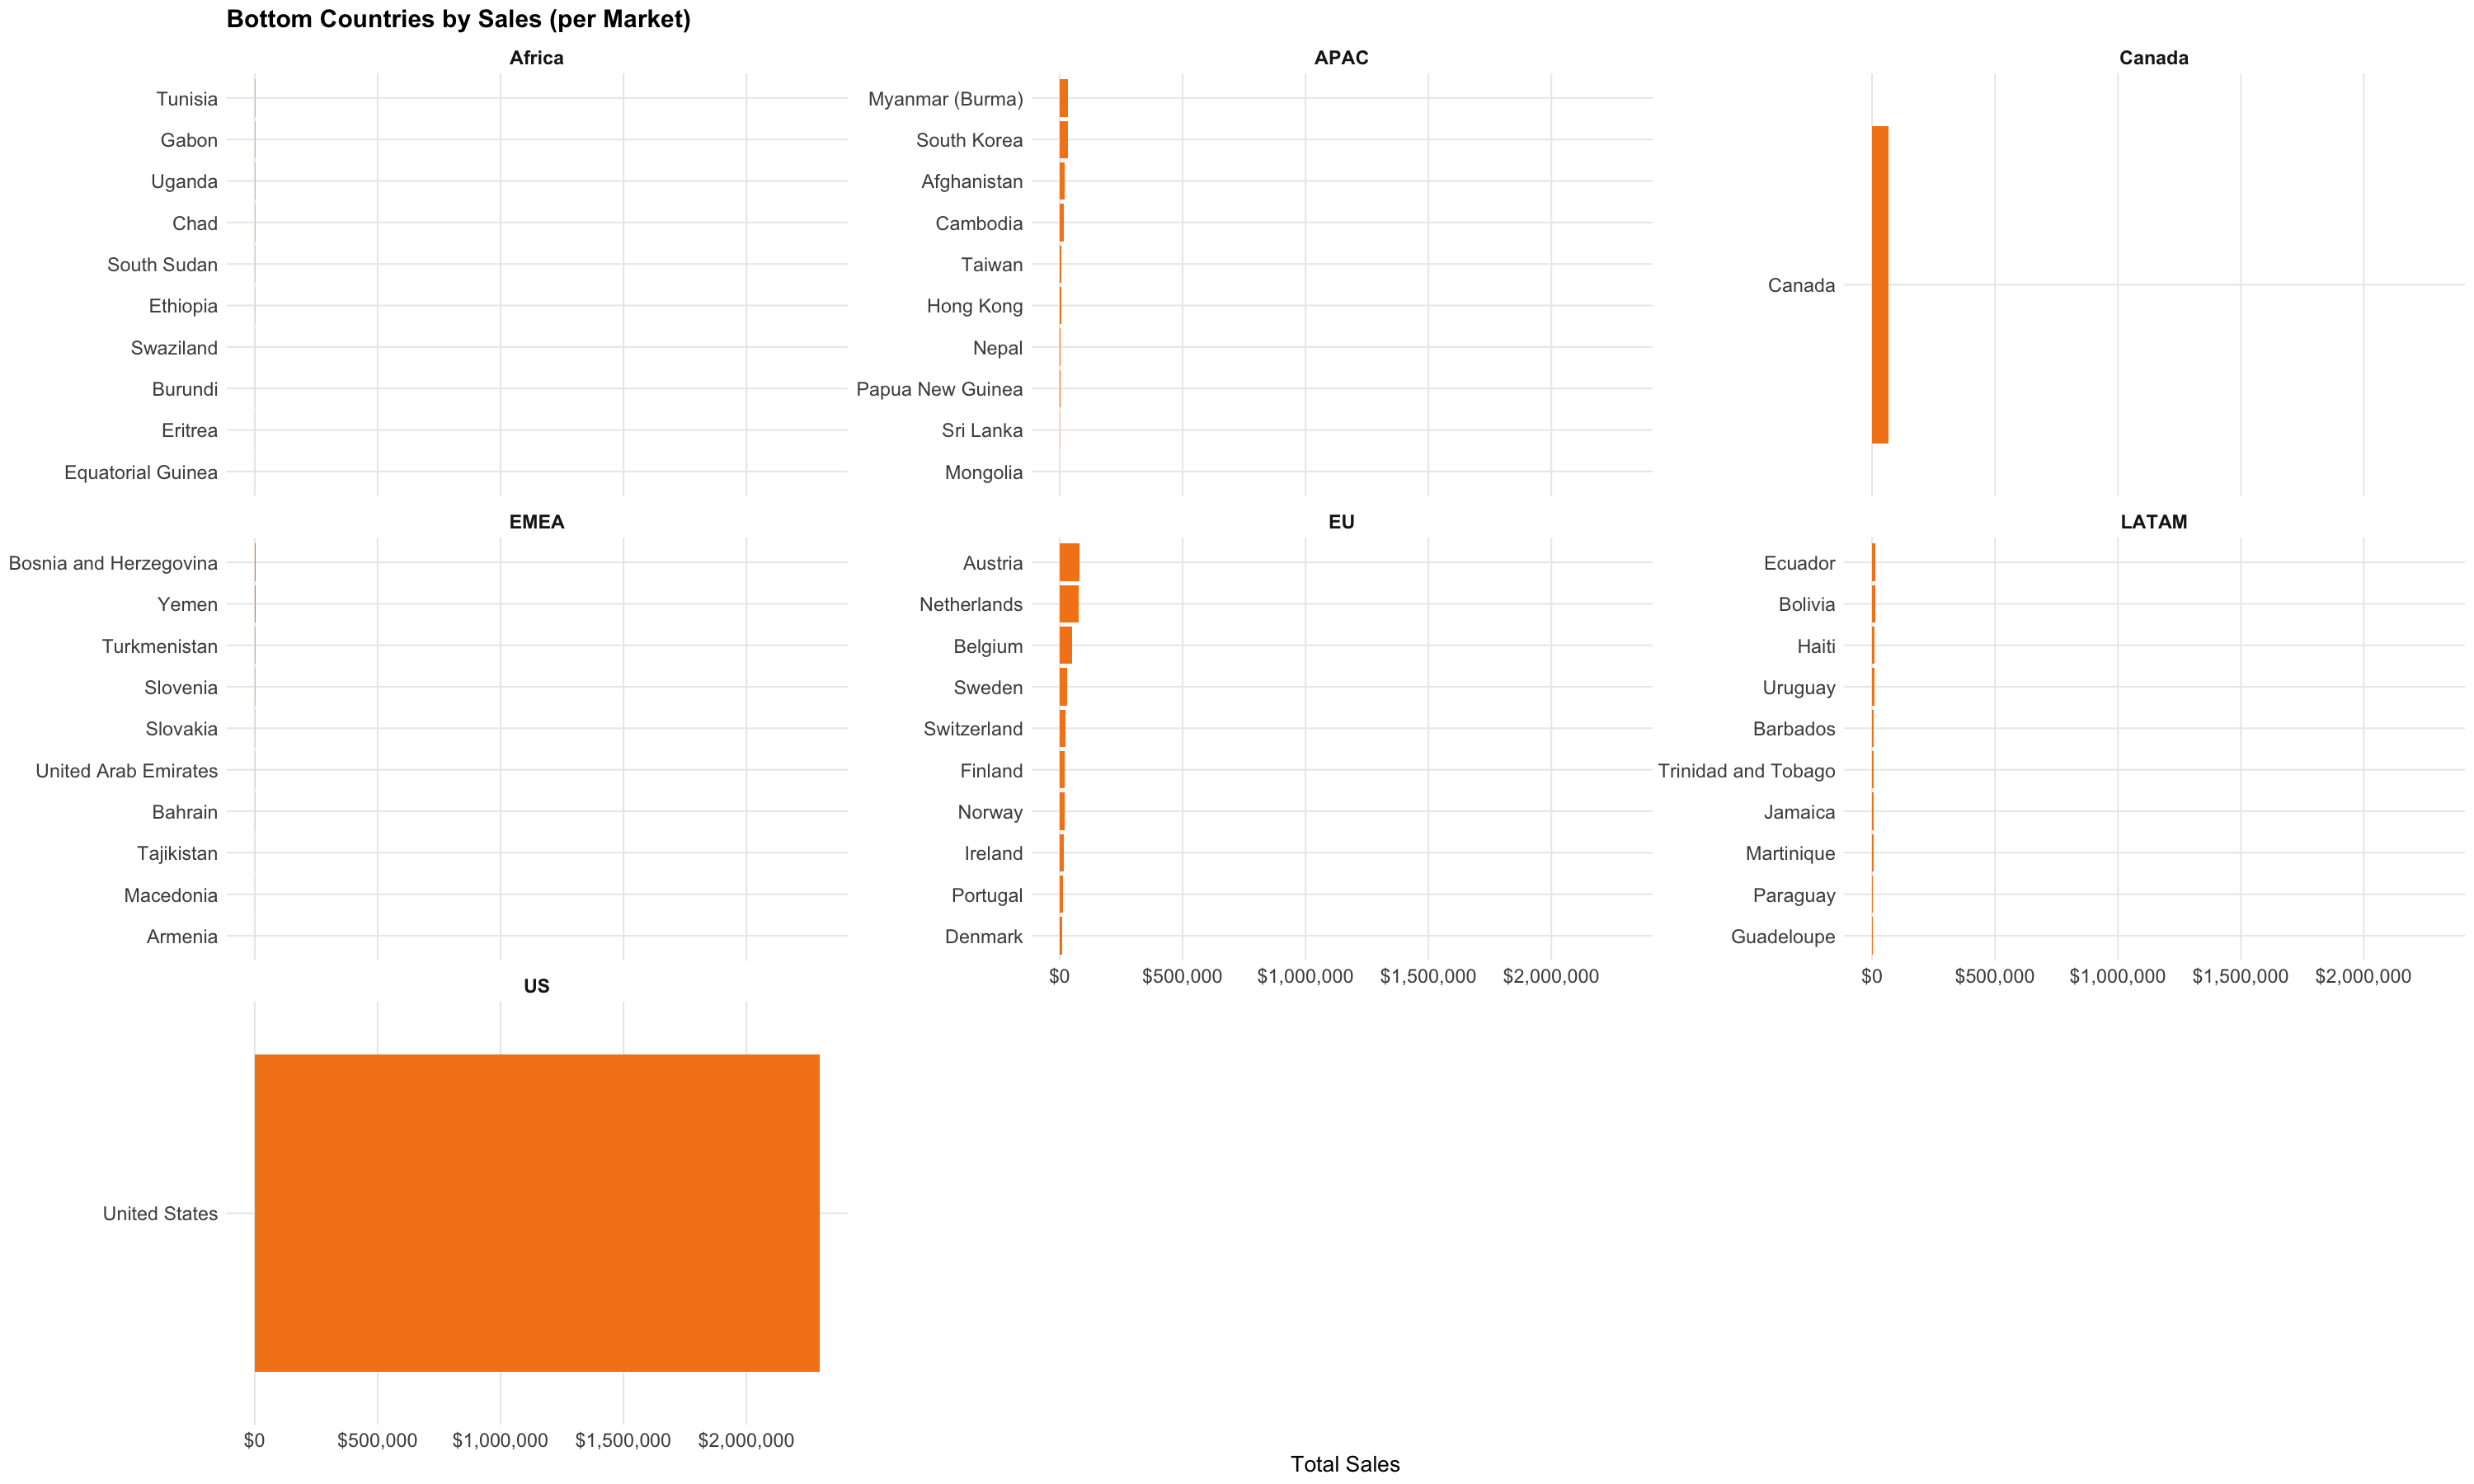

In [148]:
ggplot(
    bottom_countries,
    aes(x = reorder(country, total_sales), y = total_sales)
) +
    geom_col(fill = geo_fill_alt) +
    coord_flip() +
    facet_wrap(~market, scales = "free_y") +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Bottom Countries by Sales (per Market)",
        x = NULL,
        y = "Total Sales"
    ) 

### Profit Margin by Country (Top/Bottom N only)

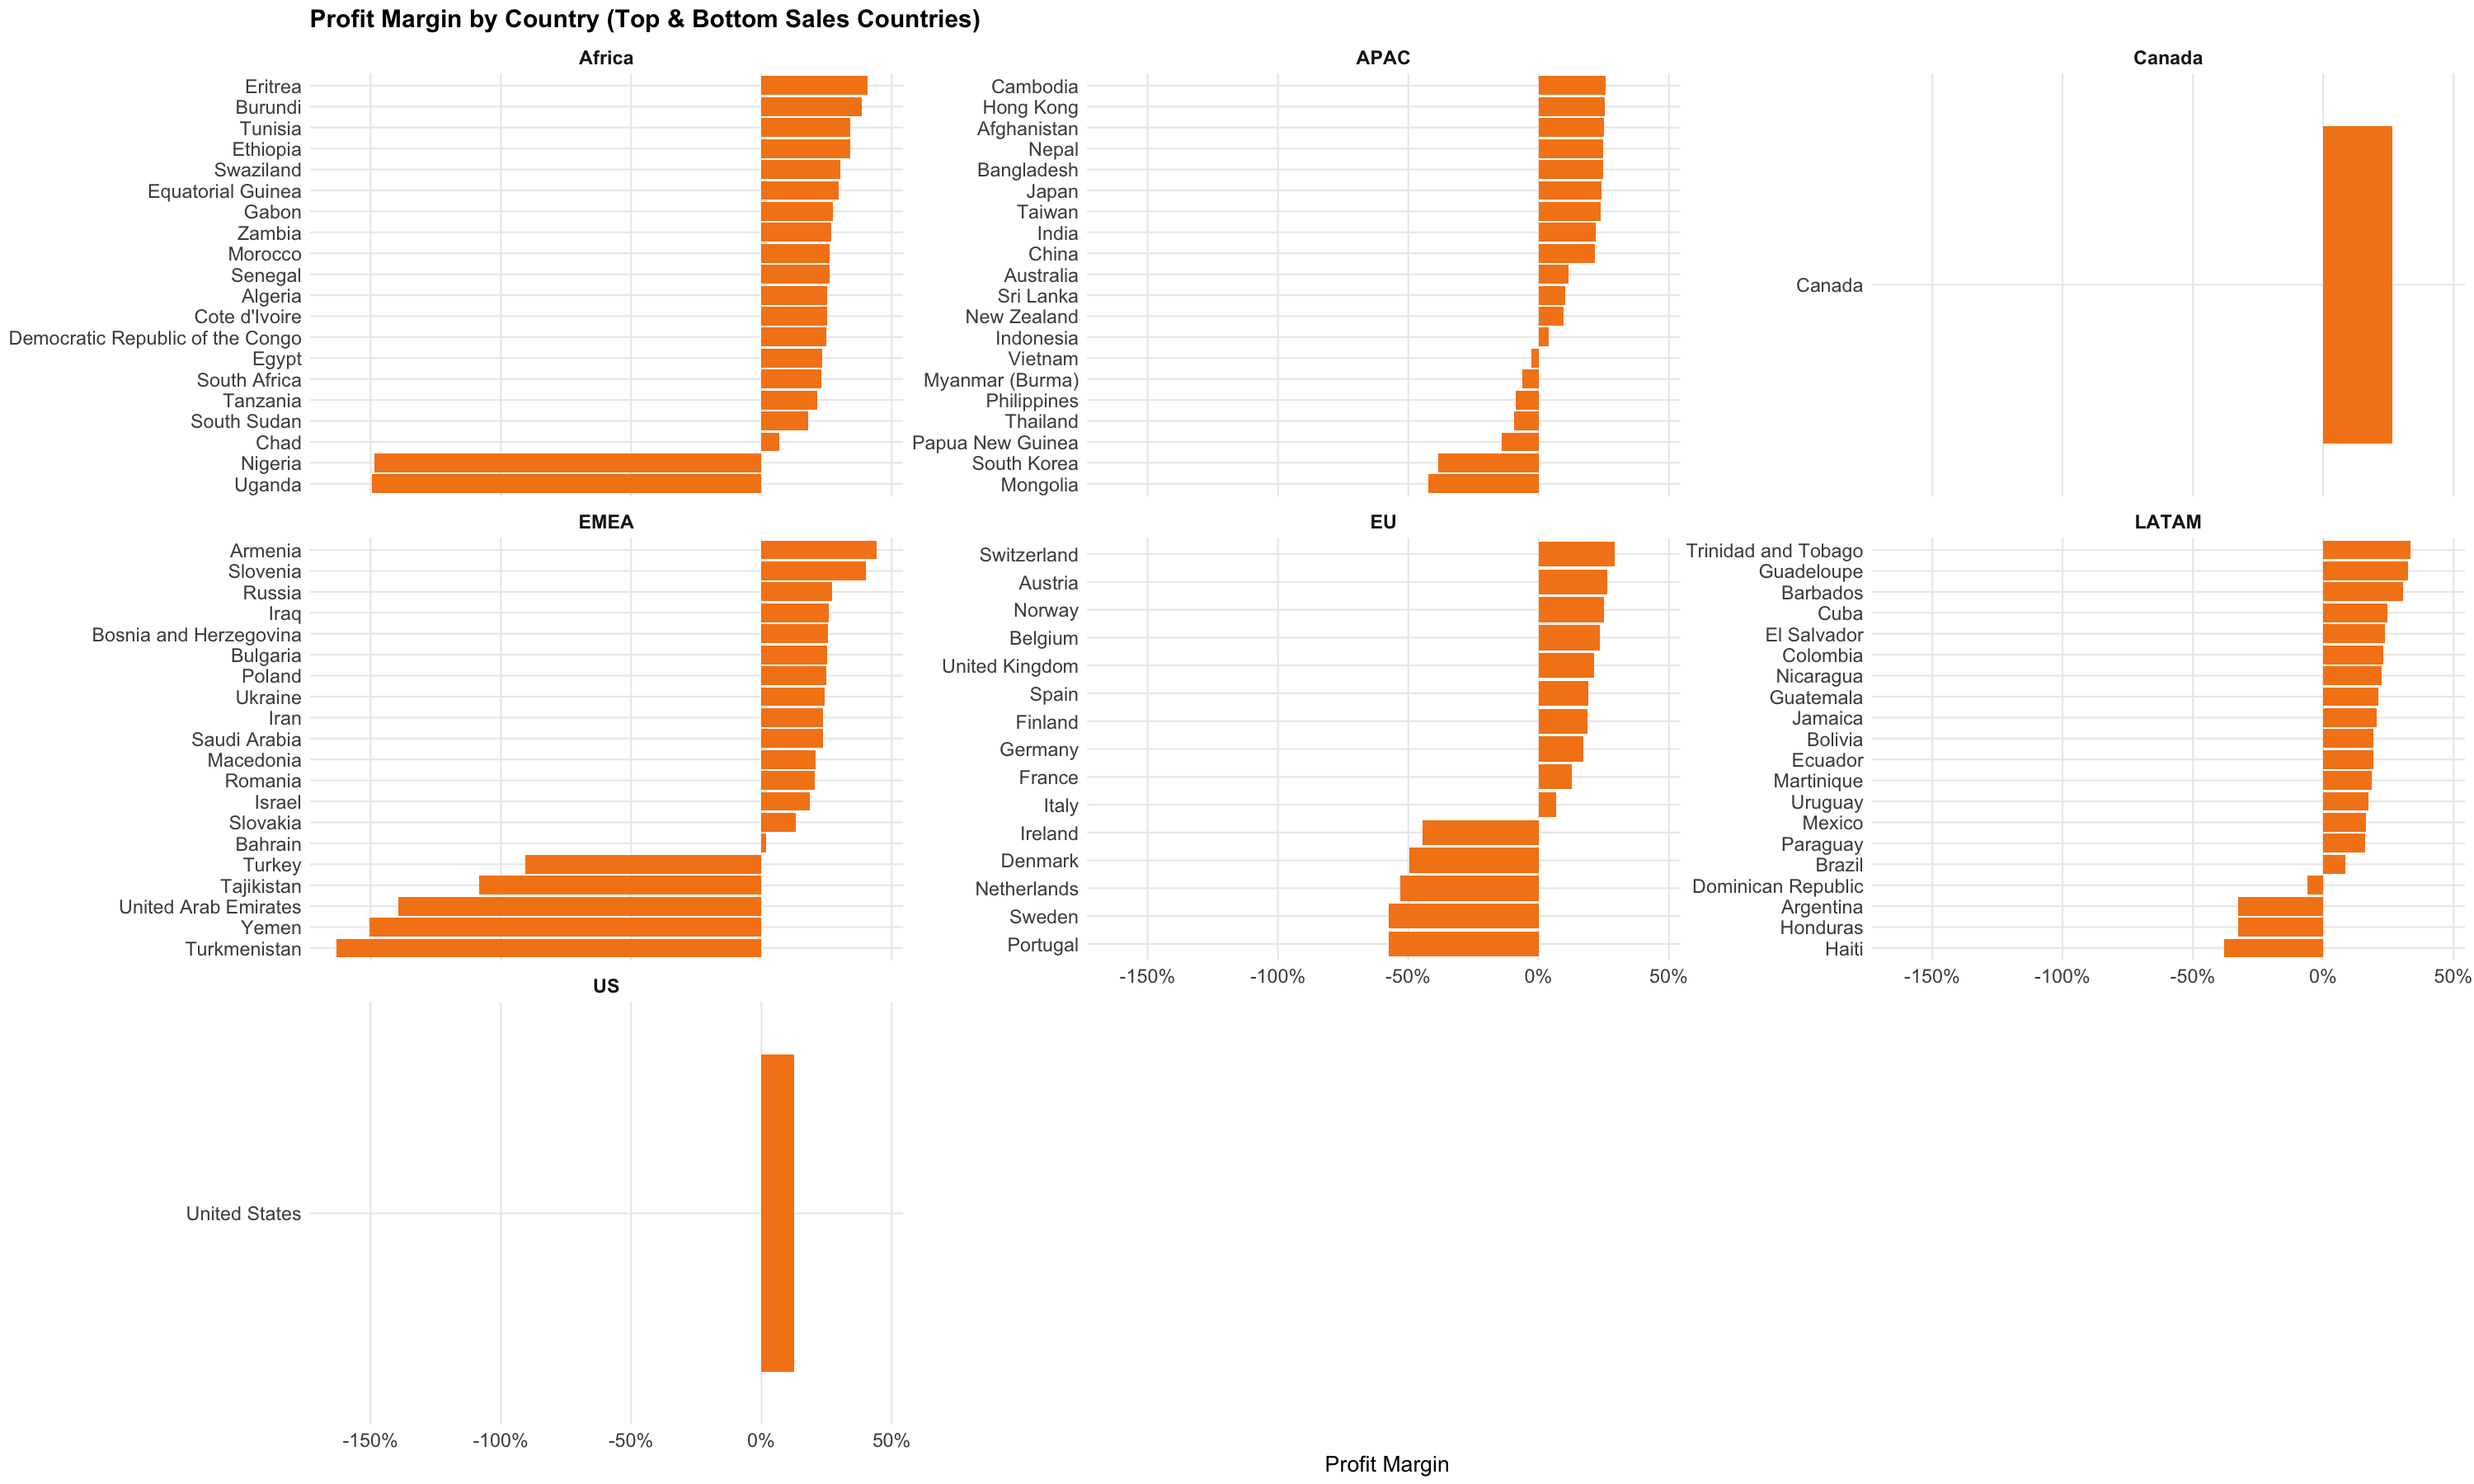

In [149]:
country_margin <- orders |> 
    group_by(market, country) |> 
    summarise(
        total_sales = sum(sales),
        total_profit = sum(profit),
        profit_margin = total_profit / total_sales,
        .groups = "drop"
    )

focus_countries <- bind_rows(
    top_countries |> select(market, country),
    bottom_countries |> select(market, country)
) |> 
    distinct()

country_margin_focus <- country_margin |> 
    inner_join(focus_countries, by = c("market", "country"))

ggplot(
    country_margin_focus,
    aes(x = reorder(country, profit_margin), y = profit_margin)
) +
    geom_col(fill = geo_fill_alt) +
    coord_flip() +
    facet_wrap(~market, scales = "free_y") +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
    labs(
        title = "Profit Margin by Country (Top & Bottom Sales Countries)",
        x = NULL,
        y = "Profit Margin"
    ) 

### Sales vs Profit by Country

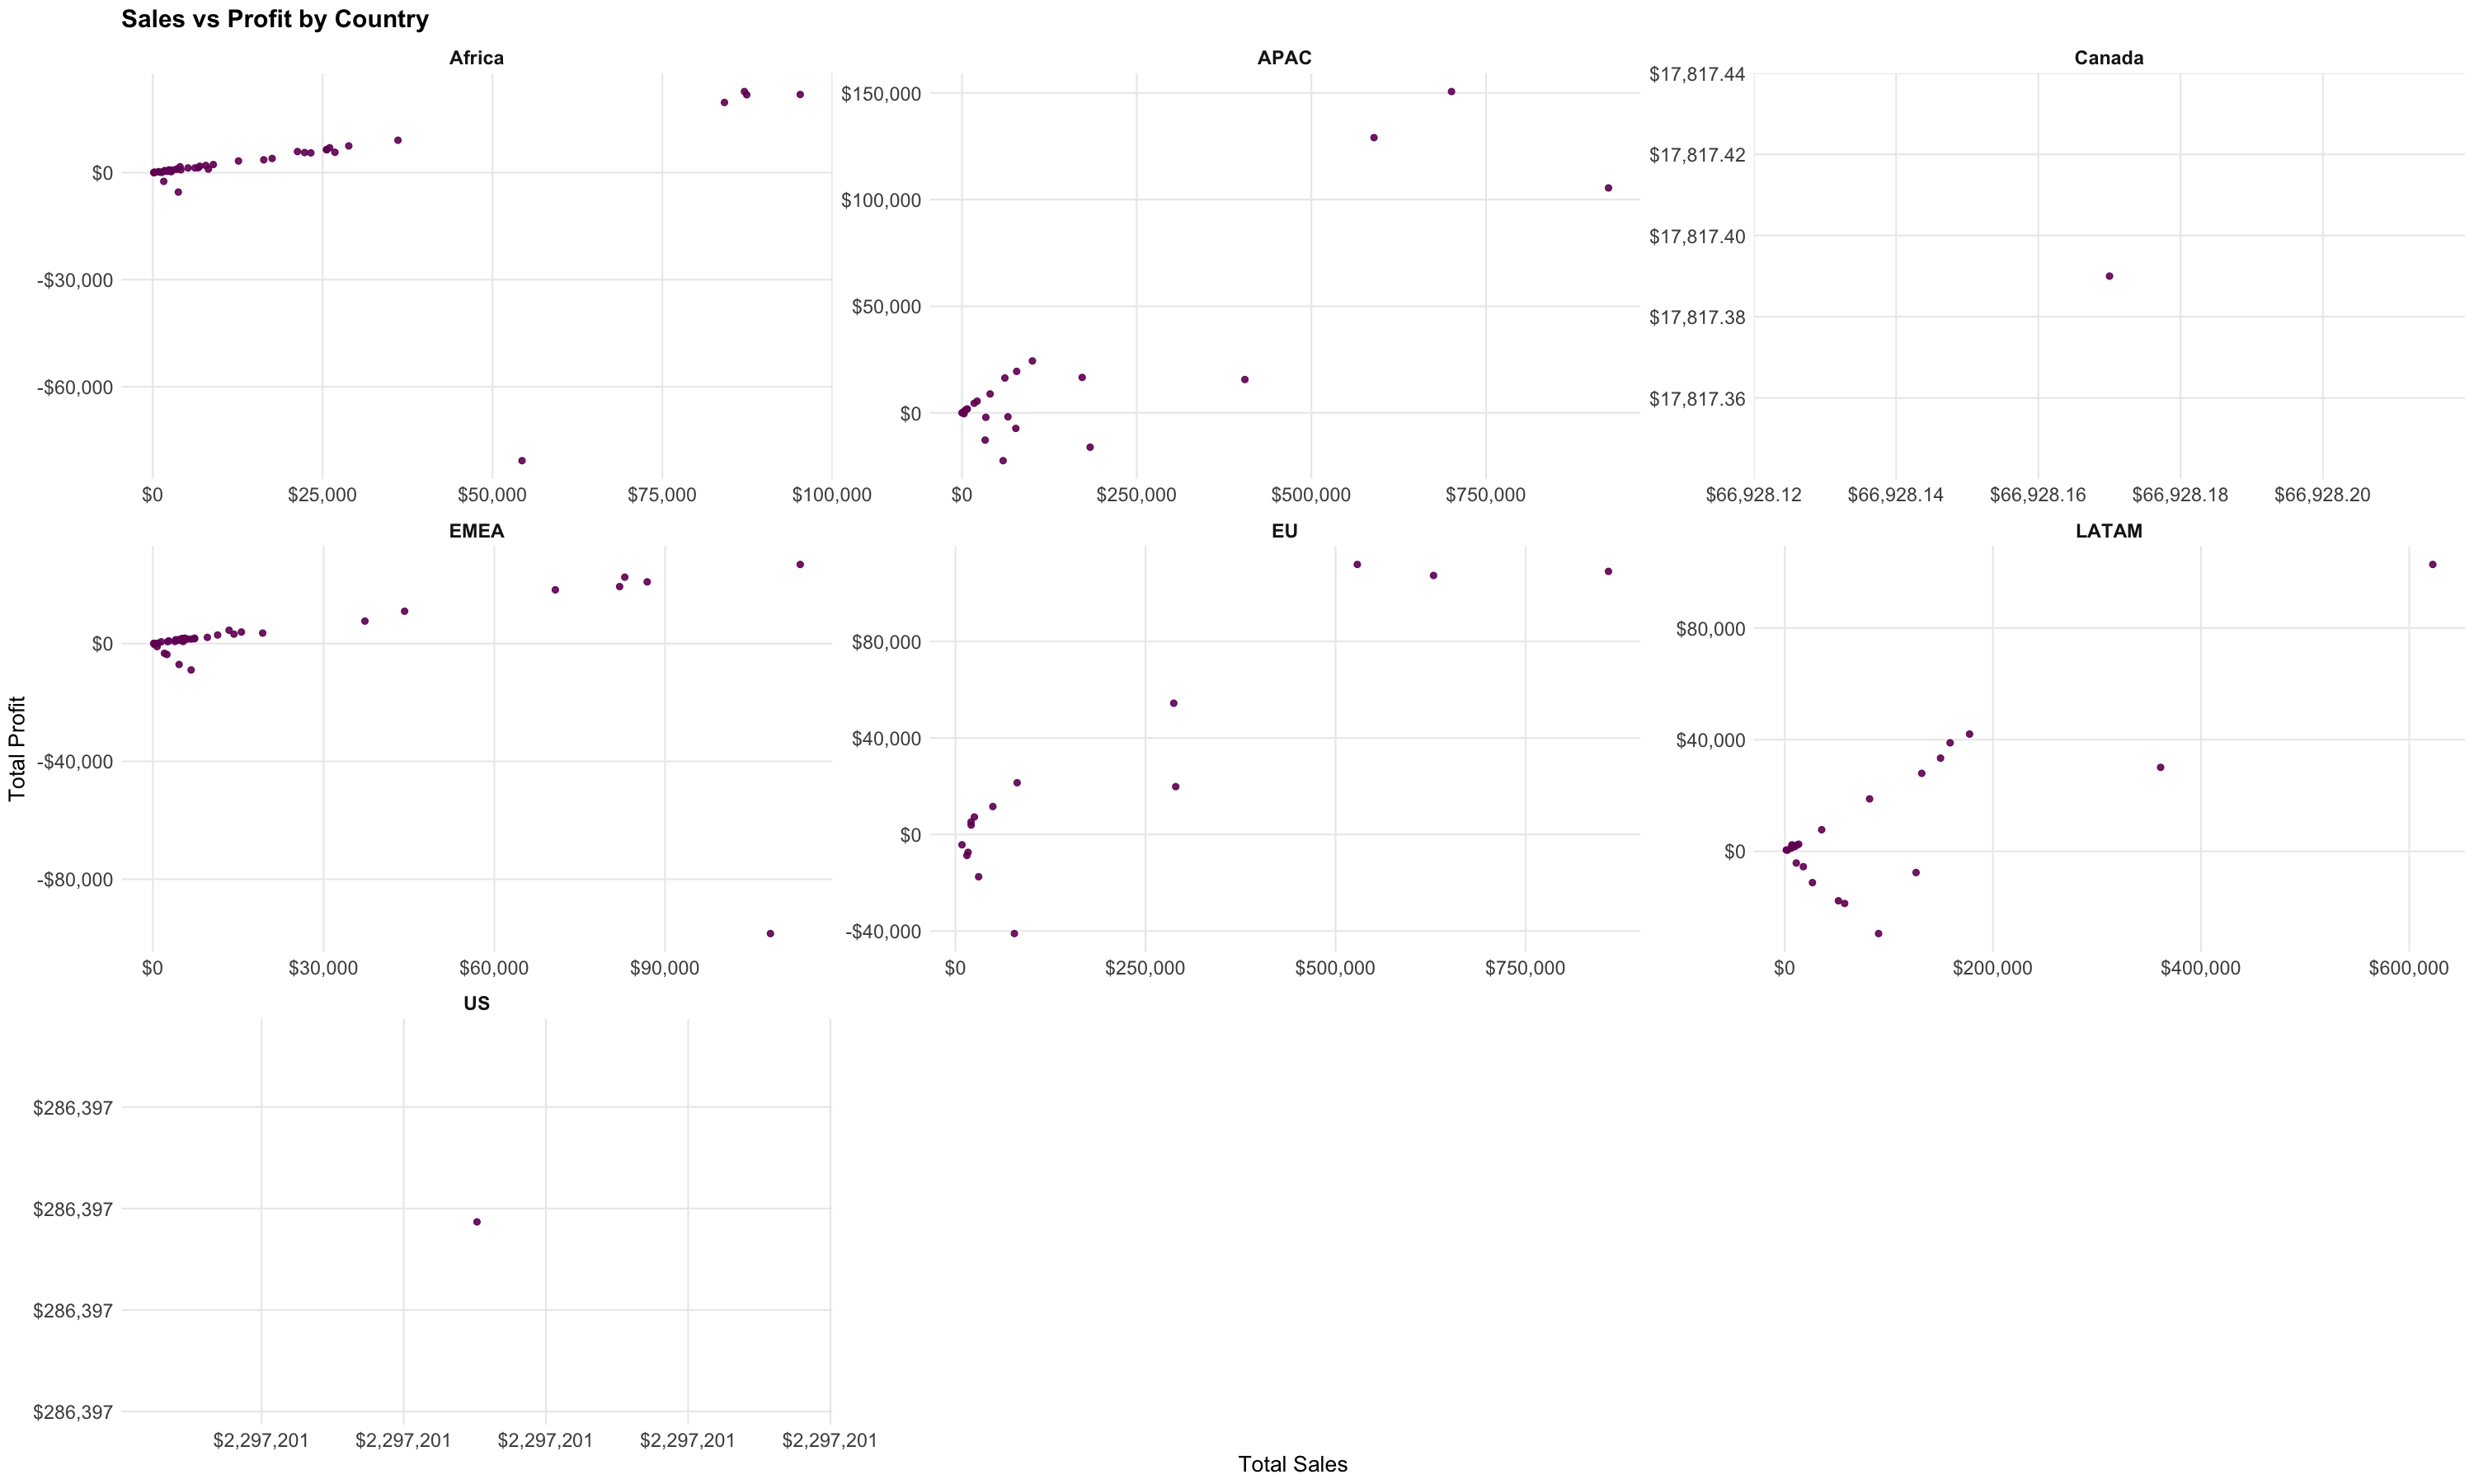

In [150]:
ggplot(
    country_margin,
    aes(x = total_sales, y = total_profit)
) +
    geom_point(alpha = 0.9, color = "#730064ff") +
    facet_wrap(~market, scales = "free") +
    scale_x_continuous(labels = scales::dollar_format()) +
    scale_y_continuous(labels = scales::dollar_format()) +
    labs(
        title = "Sales vs Profit by Country",
        x = "Total Sales",
        y = "Total Profit"
    ) 

### Section Interpretation 

The country-level analysis shows that performance within each market is highly uneven. The top-country charts identify the strongest sales contributors, while the bottom-country charts highlight locations with weak commercial traction. Profit margin for the top and bottom sales countries helps determine whether weak sales are also associated with weak profitability, or whether some countries remain efficient despite low volume. The country scatterplots are useful because they separate revenue generation from profit generation. Countries with strong sales but weak profit may require closer investigation into discounting, shipping costs, or product mix, while countries with modest sales but healthy profit may represent more efficient commercial positions.

## Geographic Risk and Volatility

### Profit Margin Distribution by Market

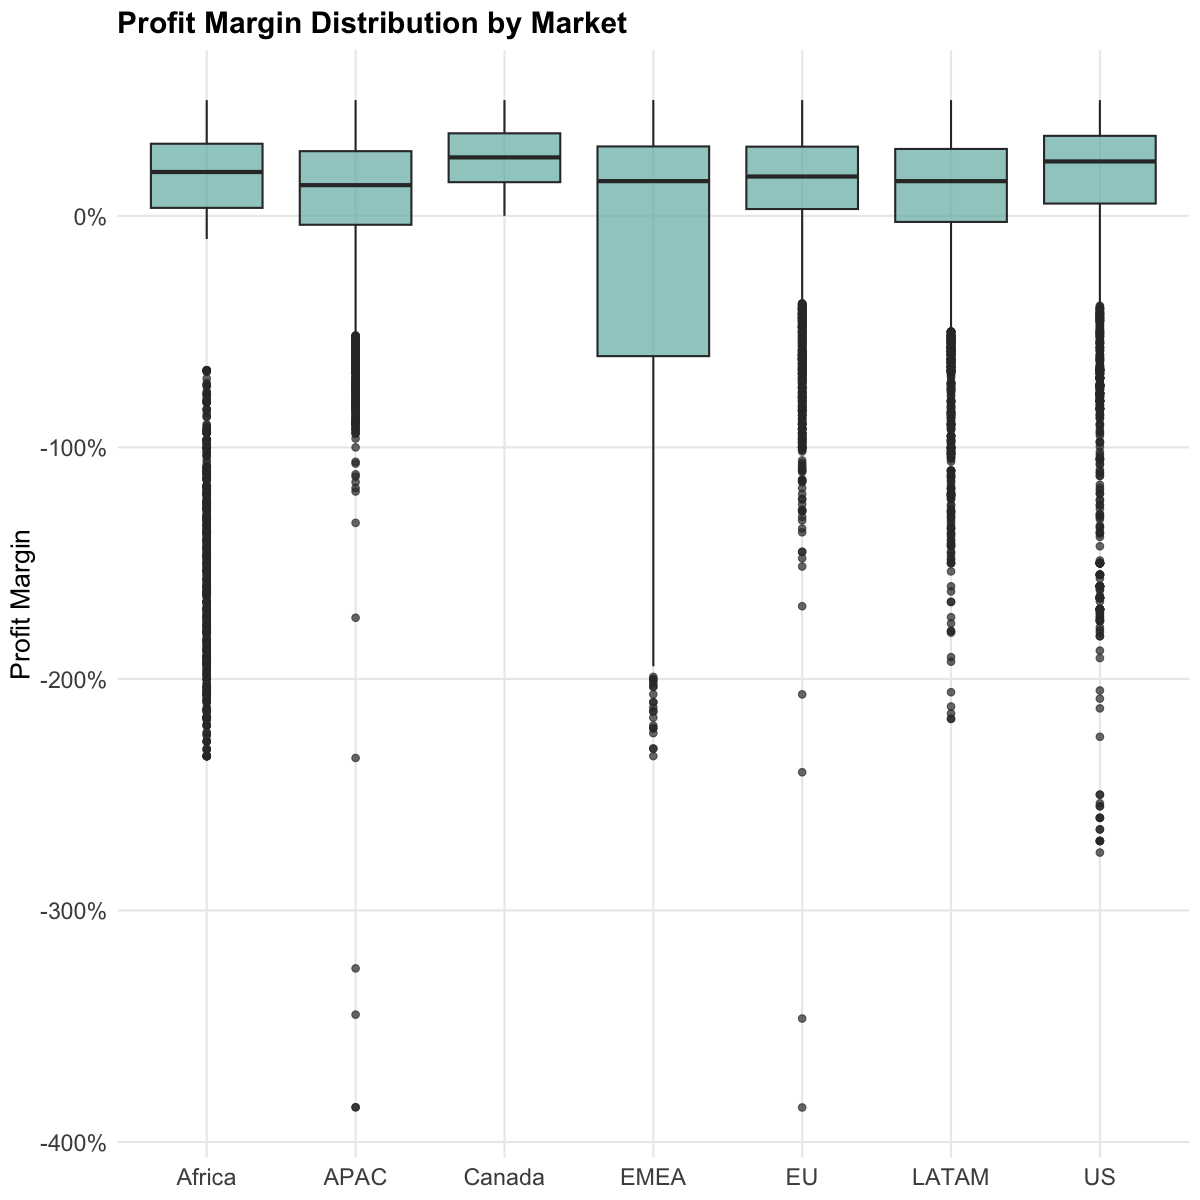

In [151]:
options(repr.plot.width = 10, repr.plot.height = 10)

market_margin <- orders |> 
    group_by(market, order_id) |> 
    summarise(
        sales = sum(sales),
        profit = sum(profit),
        profit_margin = profit / sales,
        .groups = "drop"
    )

ggplot(
    market_margin,
    aes(x = market, y = profit_margin)
) +
    geom_boxplot(fill = geo_fill_soft, alpha = 0.7) +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Profit Margin Distribution by Market",
        x = NULL,
        y = "Profit Margin"
    ) 

### Return Rate by Region / Market

In [152]:
orders_with_returns <- orders |> 
    left_join(
        returns |> 
            distinct(order_id) |> 
            mutate(returned = 1), 
        by = "order_id"
    ) |> 
    mutate(returned = if_else(is.na(returned), 0, returned))

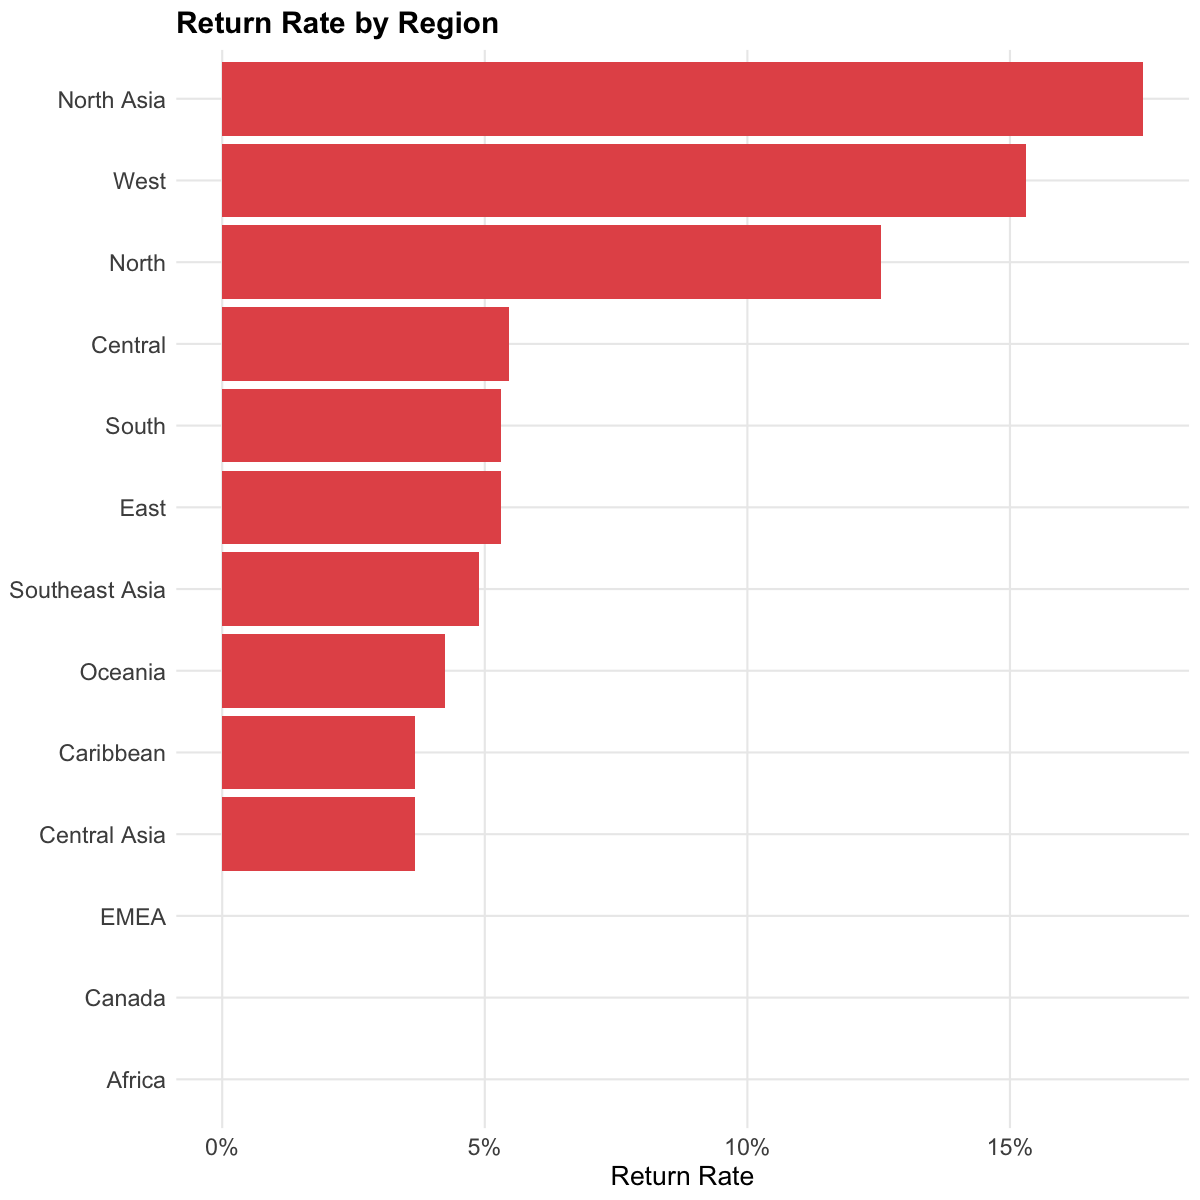

In [153]:
returns_region <- orders_with_returns |> 
    group_by(region) |> 
    summarise(
        return_rate = mean(returned), 
        .groups = "drop"
    )

ggplot(
    returns_region,
    aes(x = reorder(region, return_rate), y = return_rate)
) +
    geom_col(fill = geo_fill_risk) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Return Rate by Region",
        x = NULL,
        y = "Return Rate"
    ) 

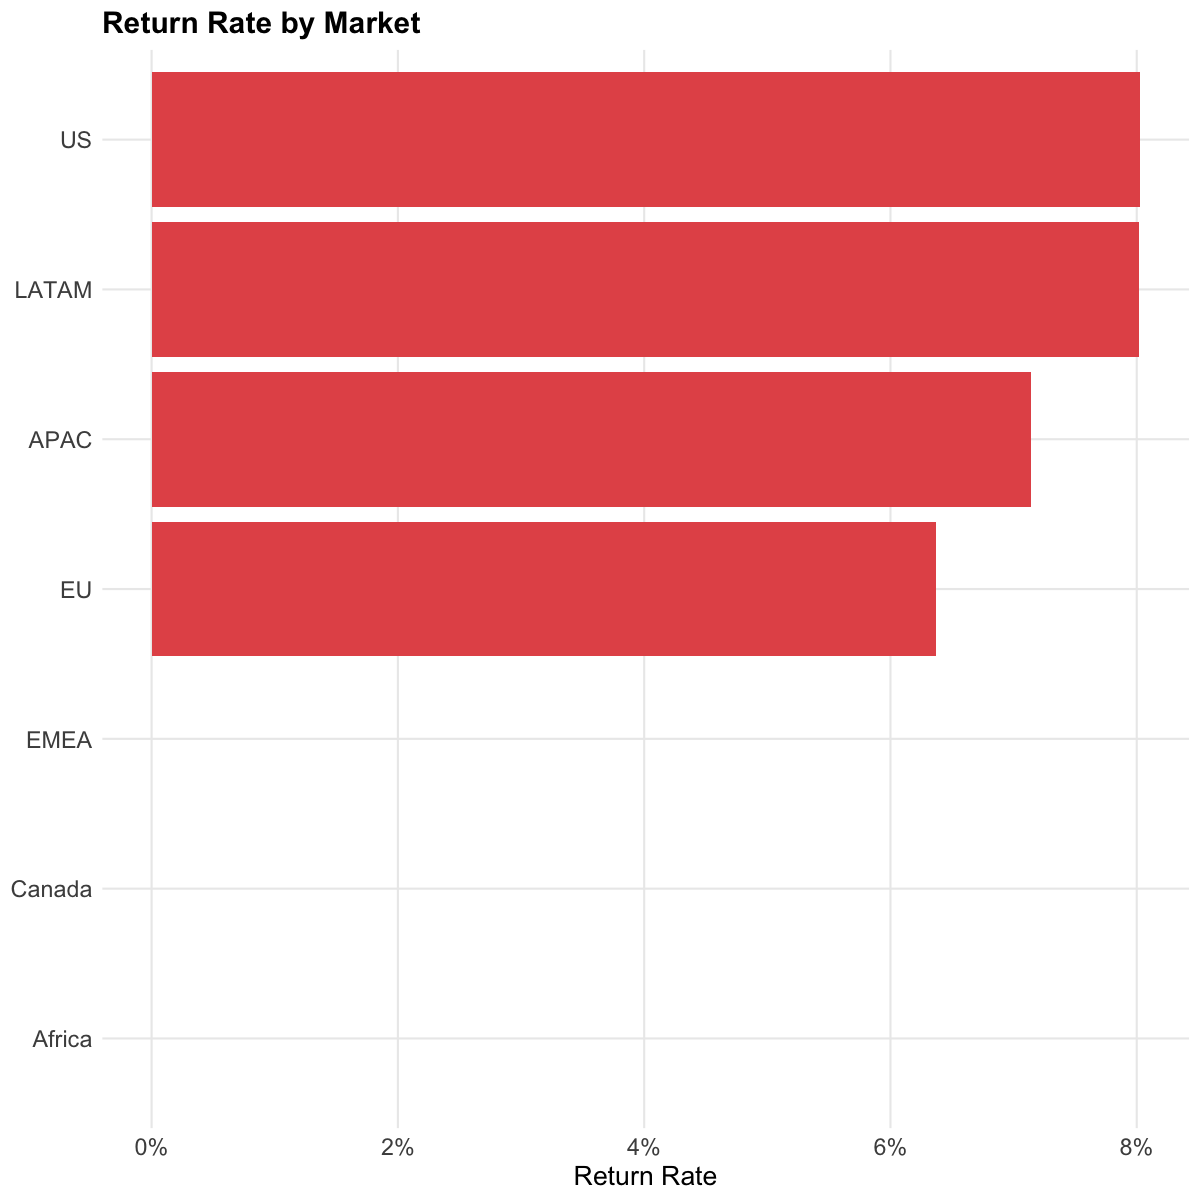

In [154]:
returns_market <- orders_with_returns |> 
    group_by(market) |> 
    summarise(
        return_rate = mean(returned), 
        .groups = "drop"
    )

ggplot(
    returns_market,
    aes(x = reorder(market, return_rate), y = return_rate)
) +
    geom_col(fill = geo_fill_risk) +
    coord_flip() +
    scale_y_continuous(labels = scales::percent_format()) +
    labs(
        title = "Return Rate by Market",
        x = NULL,
        y = "Return Rate"
    ) 

### Discount vs Profit by Region/Market (faceted)

`geom_smooth()` using formula = 'y ~ x'


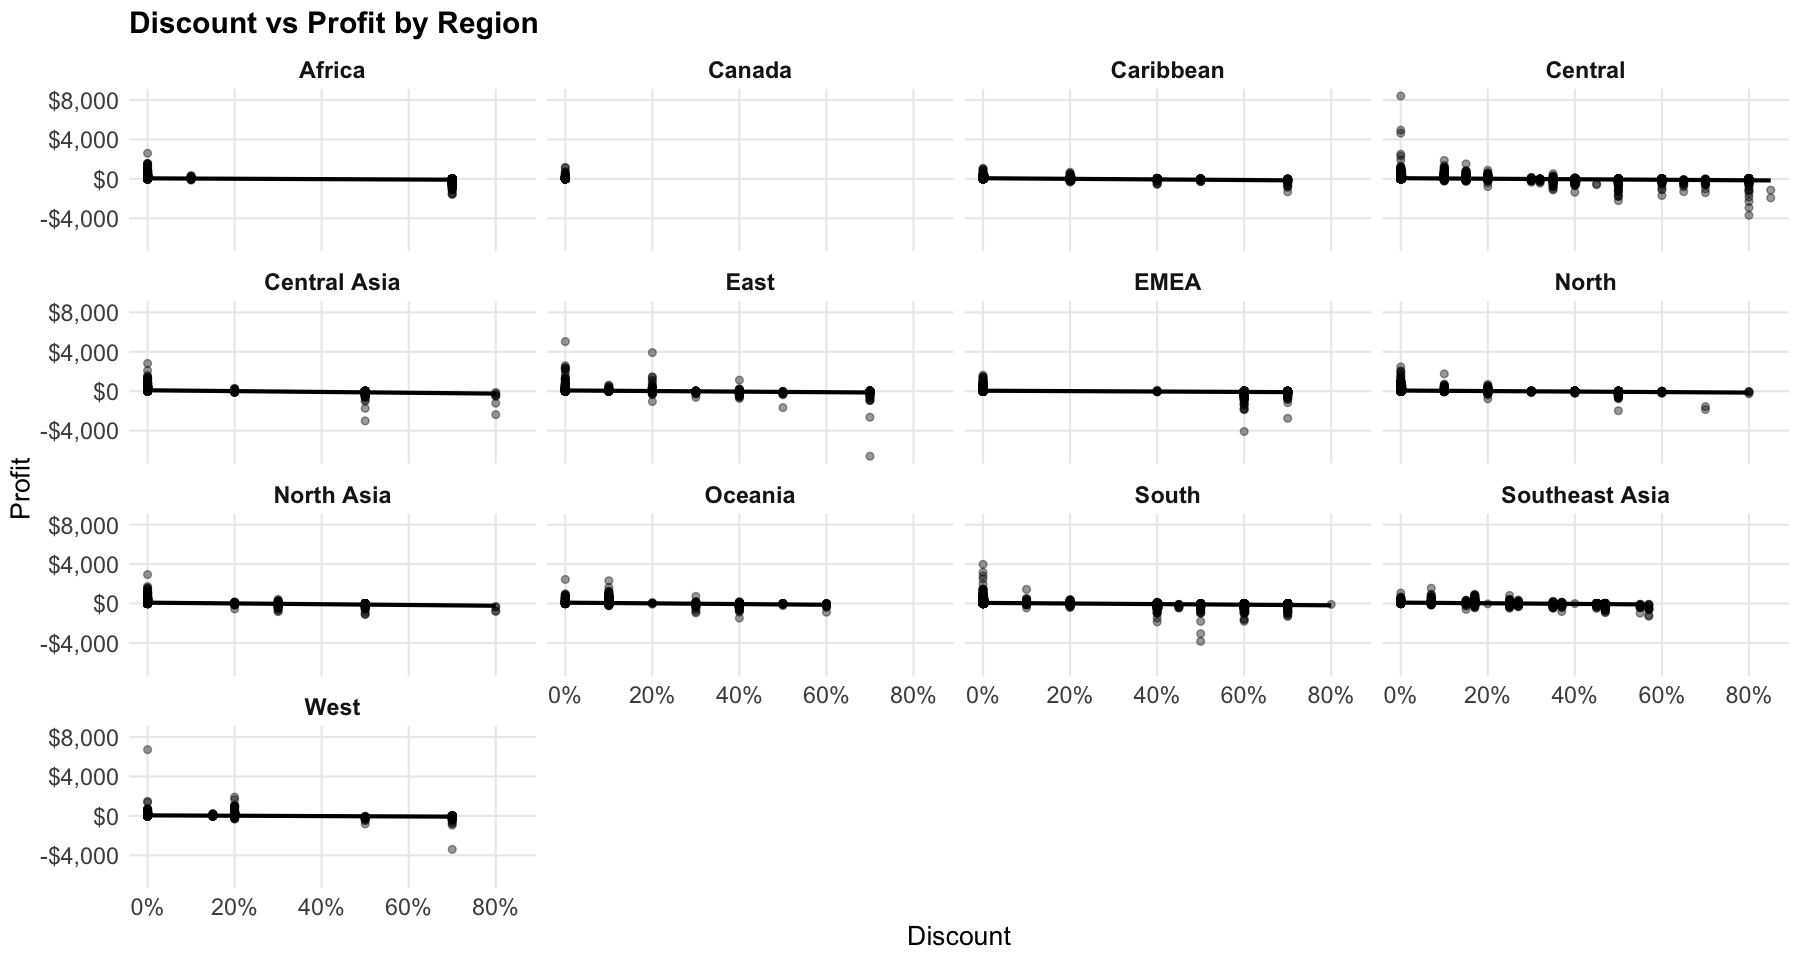

In [155]:
options(repr.plot.width = 15, repr.plot.height = 8)
ggplot(
    orders,
    aes(x = discount, y = profit)
) +
    geom_point(alpha = 0.4) +
    geom_smooth(method = "lm", se = FALSE, color = "black") +
    facet_wrap(~region) +
    scale_y_continuous(labels = scales::dollar_format()) +
    scale_x_continuous(labels = scales::percent_format()) +
    labs(
        title = "Discount vs Profit by Region",
        x = "Discount",
        y = "Profit"
    ) 

`geom_smooth()` using formula = 'y ~ x'


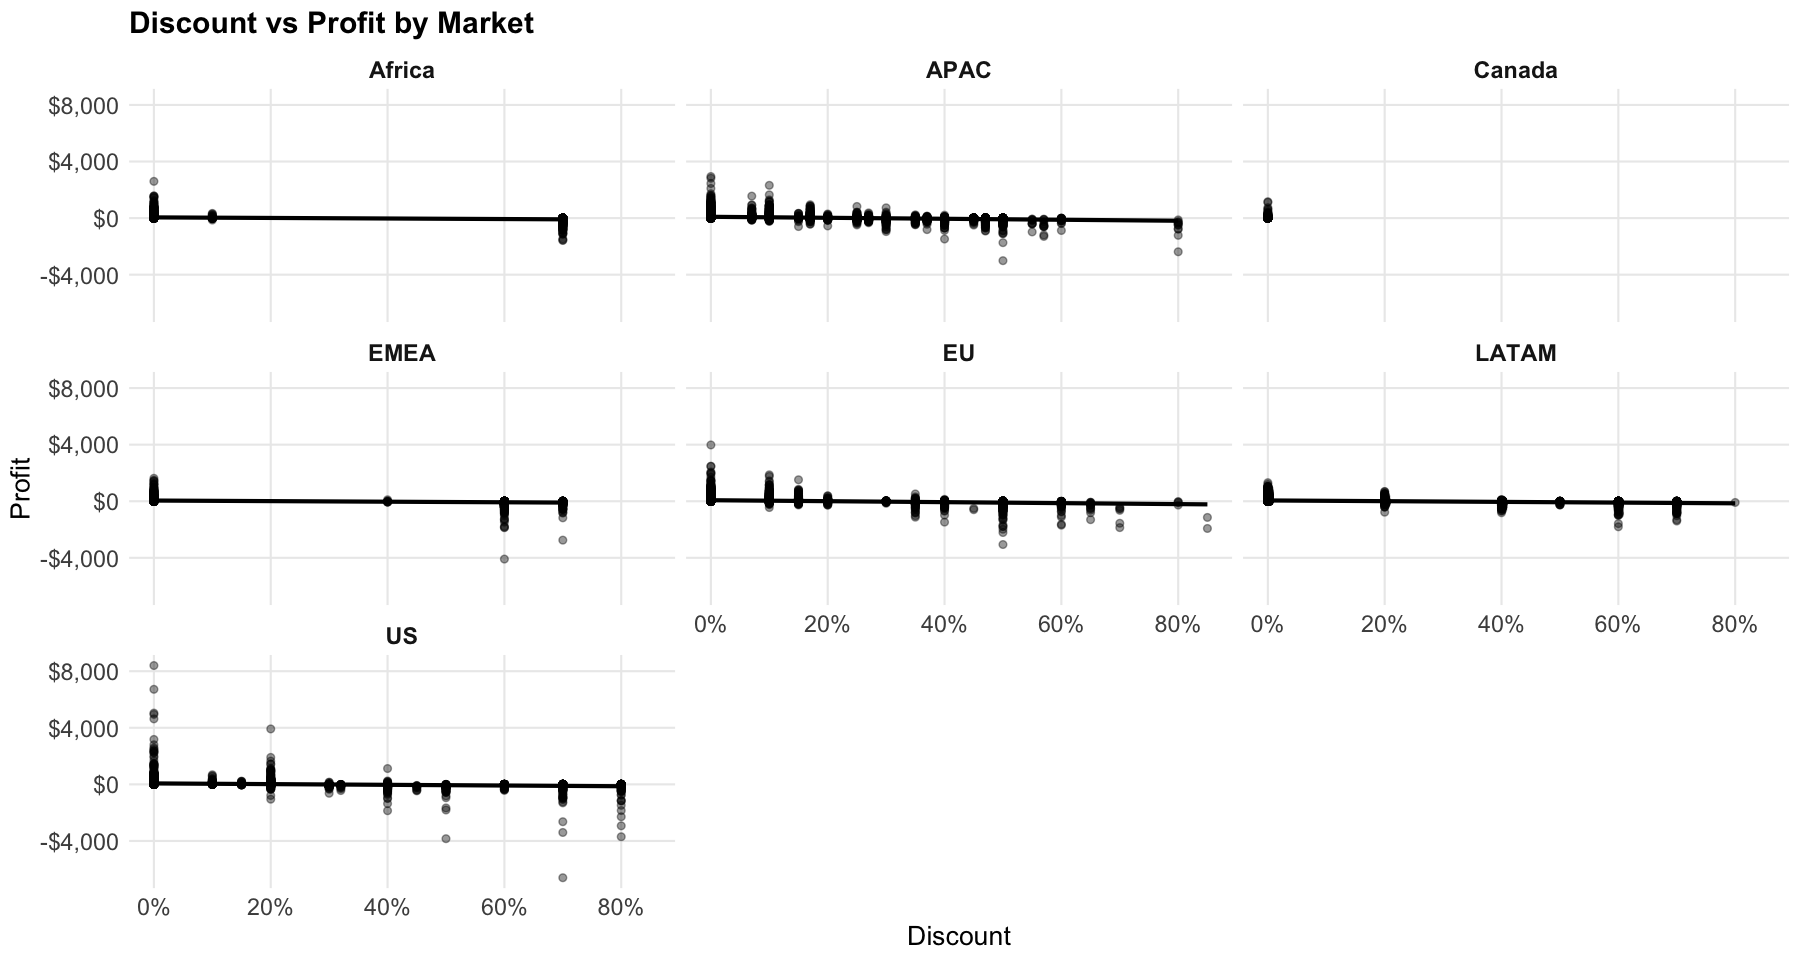

In [156]:
ggplot(
    orders,
    aes(x = discount, y = profit)
) +
    geom_point(alpha = 0.4) +
    geom_smooth(method = "lm", se = FALSE, color = "black") +
    facet_wrap(~market) +
    scale_y_continuous(labels = scales::dollar_format()) +
    scale_x_continuous(labels = scales::percent_format()) +
    labs(
        title = "Discount vs Profit by Market",
        x = "Discount",
        y = "Profit"
    )

### Interpretation 

This section focuses on the stability and risk profile of geographic performance rather than just average outcomes. Profit margin distributions show whether markets are consistently profitable or highly variable across orders. Return-rate comparisons reveal whether operational or customer-related problems are concentrated in specific regions or markets. The discount-versus-profit plots help assess whether aggressive discounting is associated with weaker profit outcomes geographically.

## Concentration and Dependency Analysis

### Top X% of Countries vs Region Sales Contribution

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


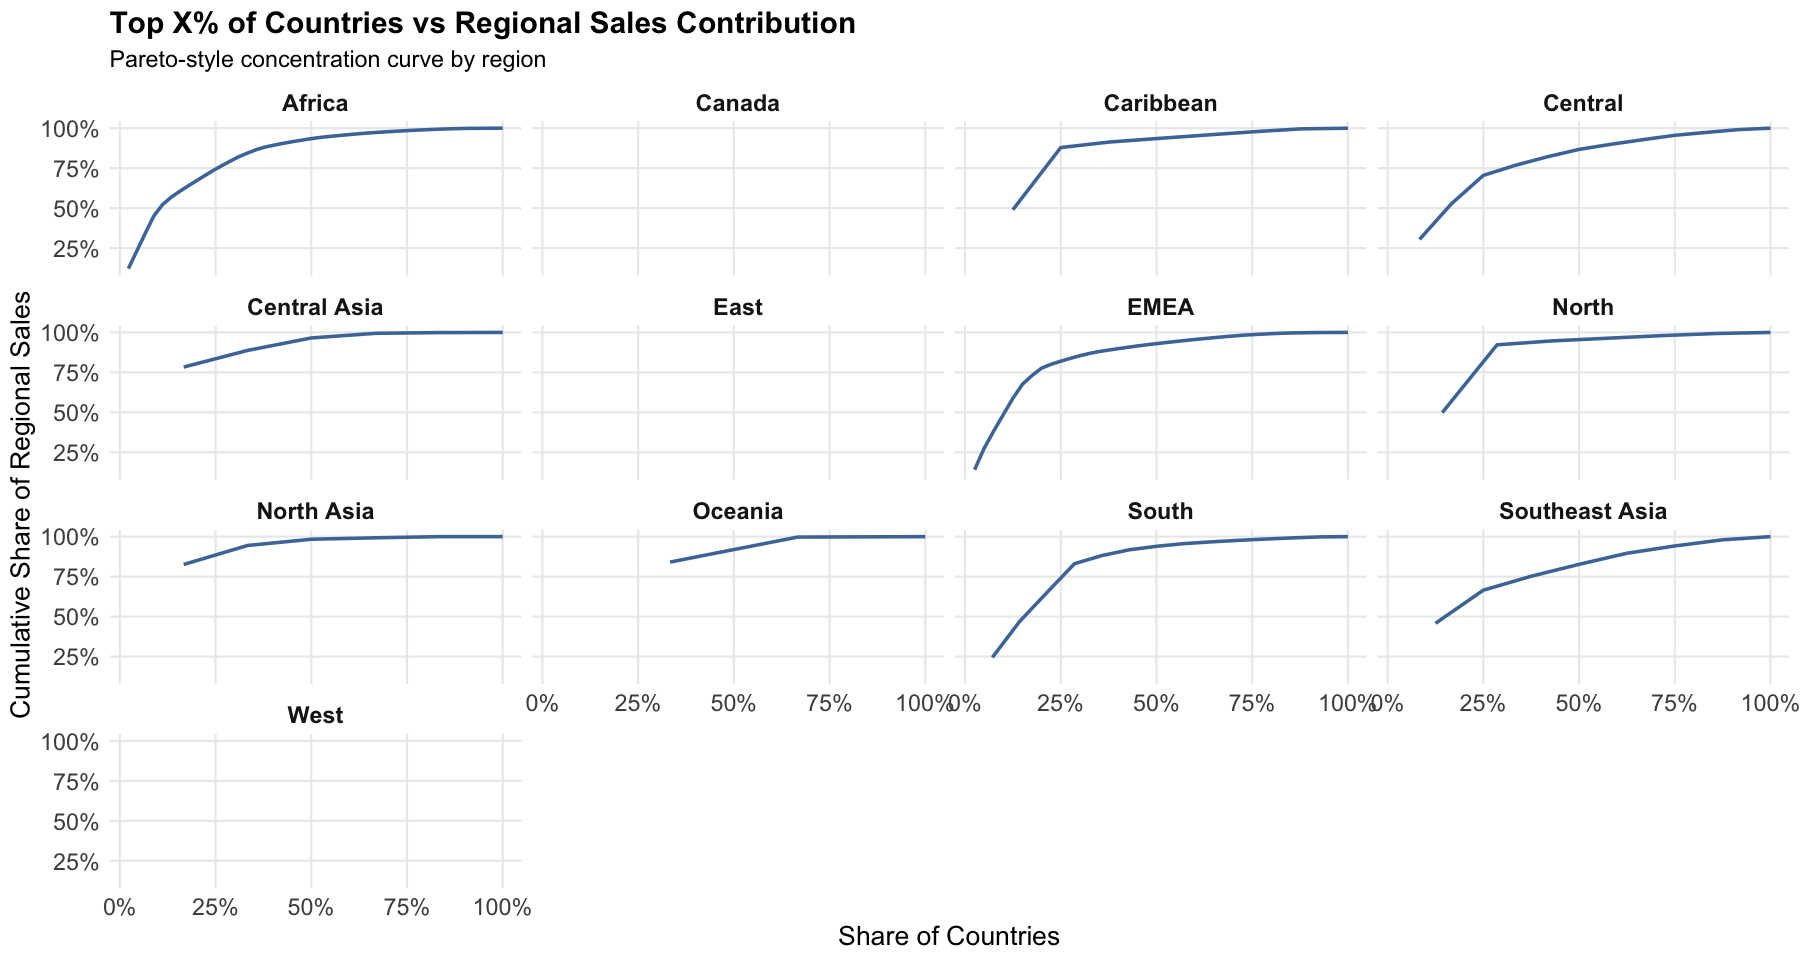

In [157]:
country_region_sales <- orders |> 
    group_by(region, country) |> 
    summarise(total_sales = sum(sales), .groups = "drop") |> 
    group_by(region) |> 
    arrange(region, desc(total_sales)) |> 
    mutate(
        country_rank = row_number(),
        country_share = country_rank / n(),
        sales_share = cumsum(total_sales) / sum(total_sales)
    )

ggplot(
    country_region_sales,
    aes(x = country_share, y = sales_share, group = region)
    ) +
    geom_line(linewidth = 1, color = geo_fill_main) +
    facet_wrap(~region) +
    scale_x_continuous(labels = percent_format()) +
    scale_y_continuous(labels = percent_format()) +
    labs(
        title = "Top X% of Countries vs Regional Sales Contribution",
        subtitle = "Pareto-style concentration curve by region",
        x = "Share of Countries",
        y = "Cumulative Share of Regional Sales"
    )

### Market concentration curves (Pareto-style)

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?
`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


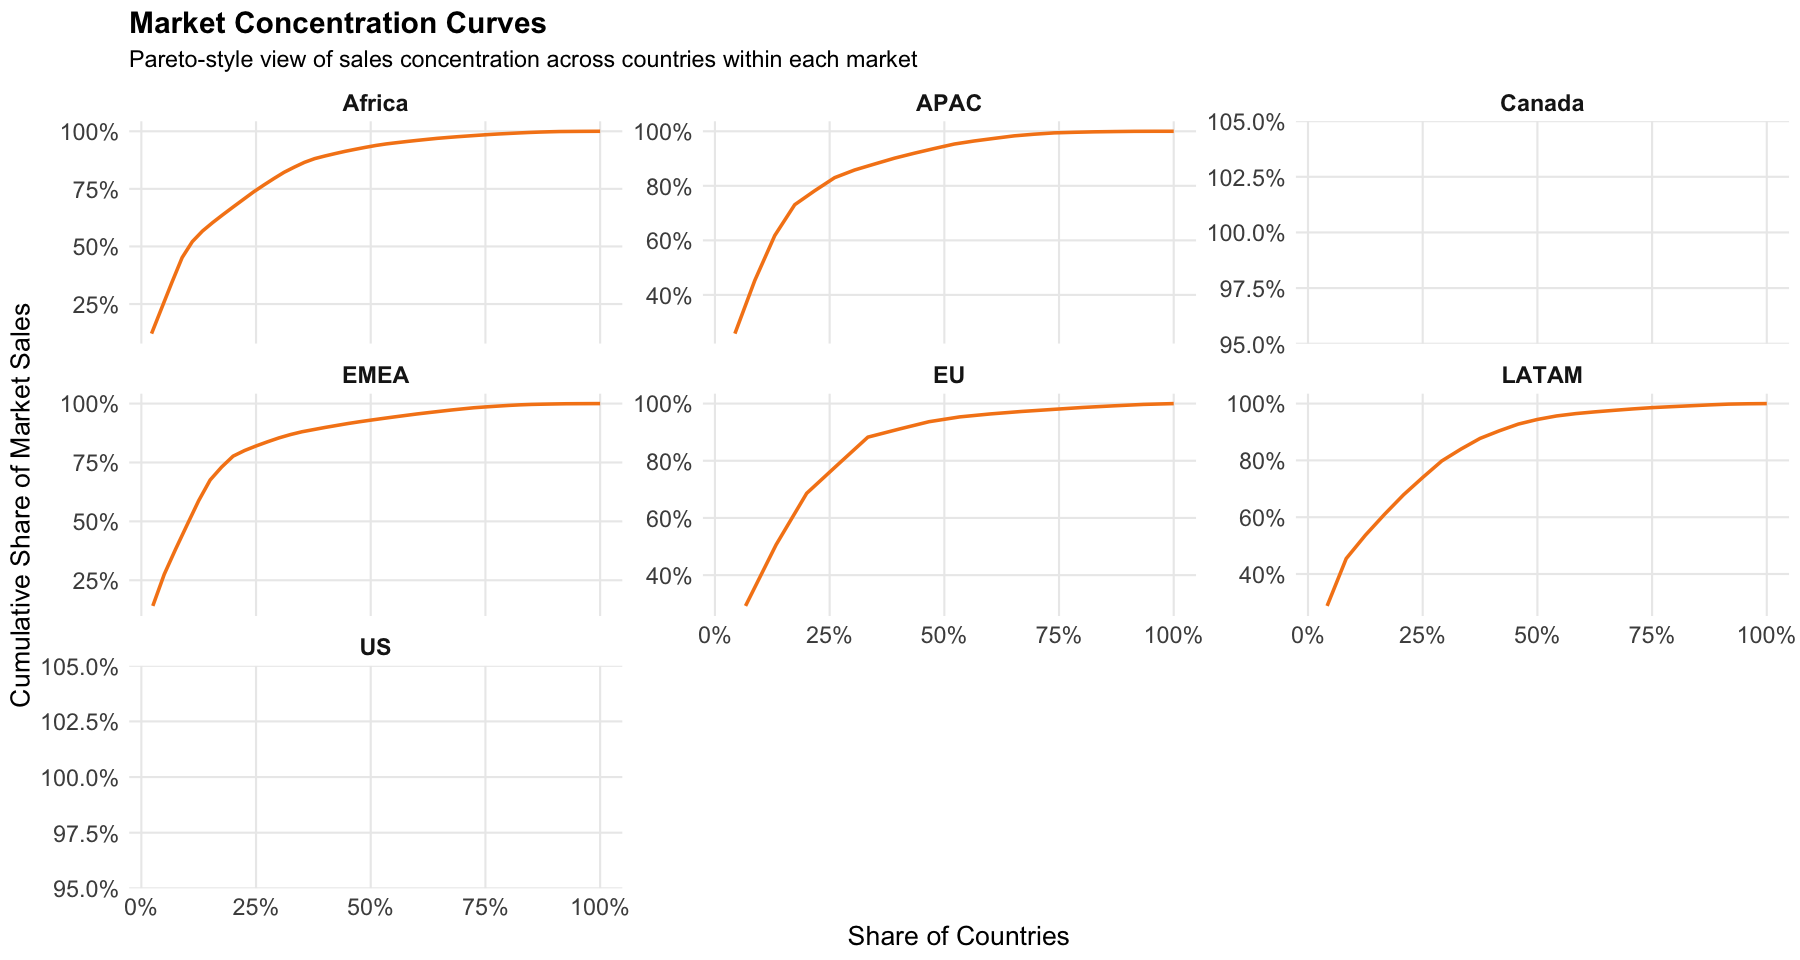

In [158]:
country_market_sales <- orders |>
    group_by(market, country) |>
    summarise(total_sales = sum(sales), .groups = "drop") |>
    group_by(market) |>
    arrange(market, desc(total_sales)) |>
    mutate(
        country_rank = row_number(),
        country_share = country_rank / n(),
        sales_share = cumsum(total_sales) / sum(total_sales)
    )

ggplot(
    country_market_sales,
    aes(x = country_share, y = sales_share, group = market)
    ) +
    geom_line(linewidth = 1, color = geo_fill_alt) +
    facet_wrap(~market, scales = "free_y") +
    scale_x_continuous(labels = percent_format()) +
    scale_y_continuous(labels = percent_format()) +
    labs(
        title = "Market Concentration Curves",
        subtitle = "Pareto-style view of sales concentration across countries within each market",
        x = "Share of Countries",
        y = "Cumulative Share of Market Sales"
    )

### Section Interpretation 

The concentration curves show how much geographic performance depends on a relatively small subset of countries. If the cumulative sales share rises quickly, this suggests that a small proportion of countries drives most of the market or regional revenue. That pattern is important because it reveals dependency risk that may not be obvious from simple total-sales charts. This section complements the earlier performance views by showing not only where revenue is generated, but also how concentrated that revenue is. Strong concentration can be commercially efficient, but it also increases exposure to disruptions in a limited number of countries.

## Geographic Map View

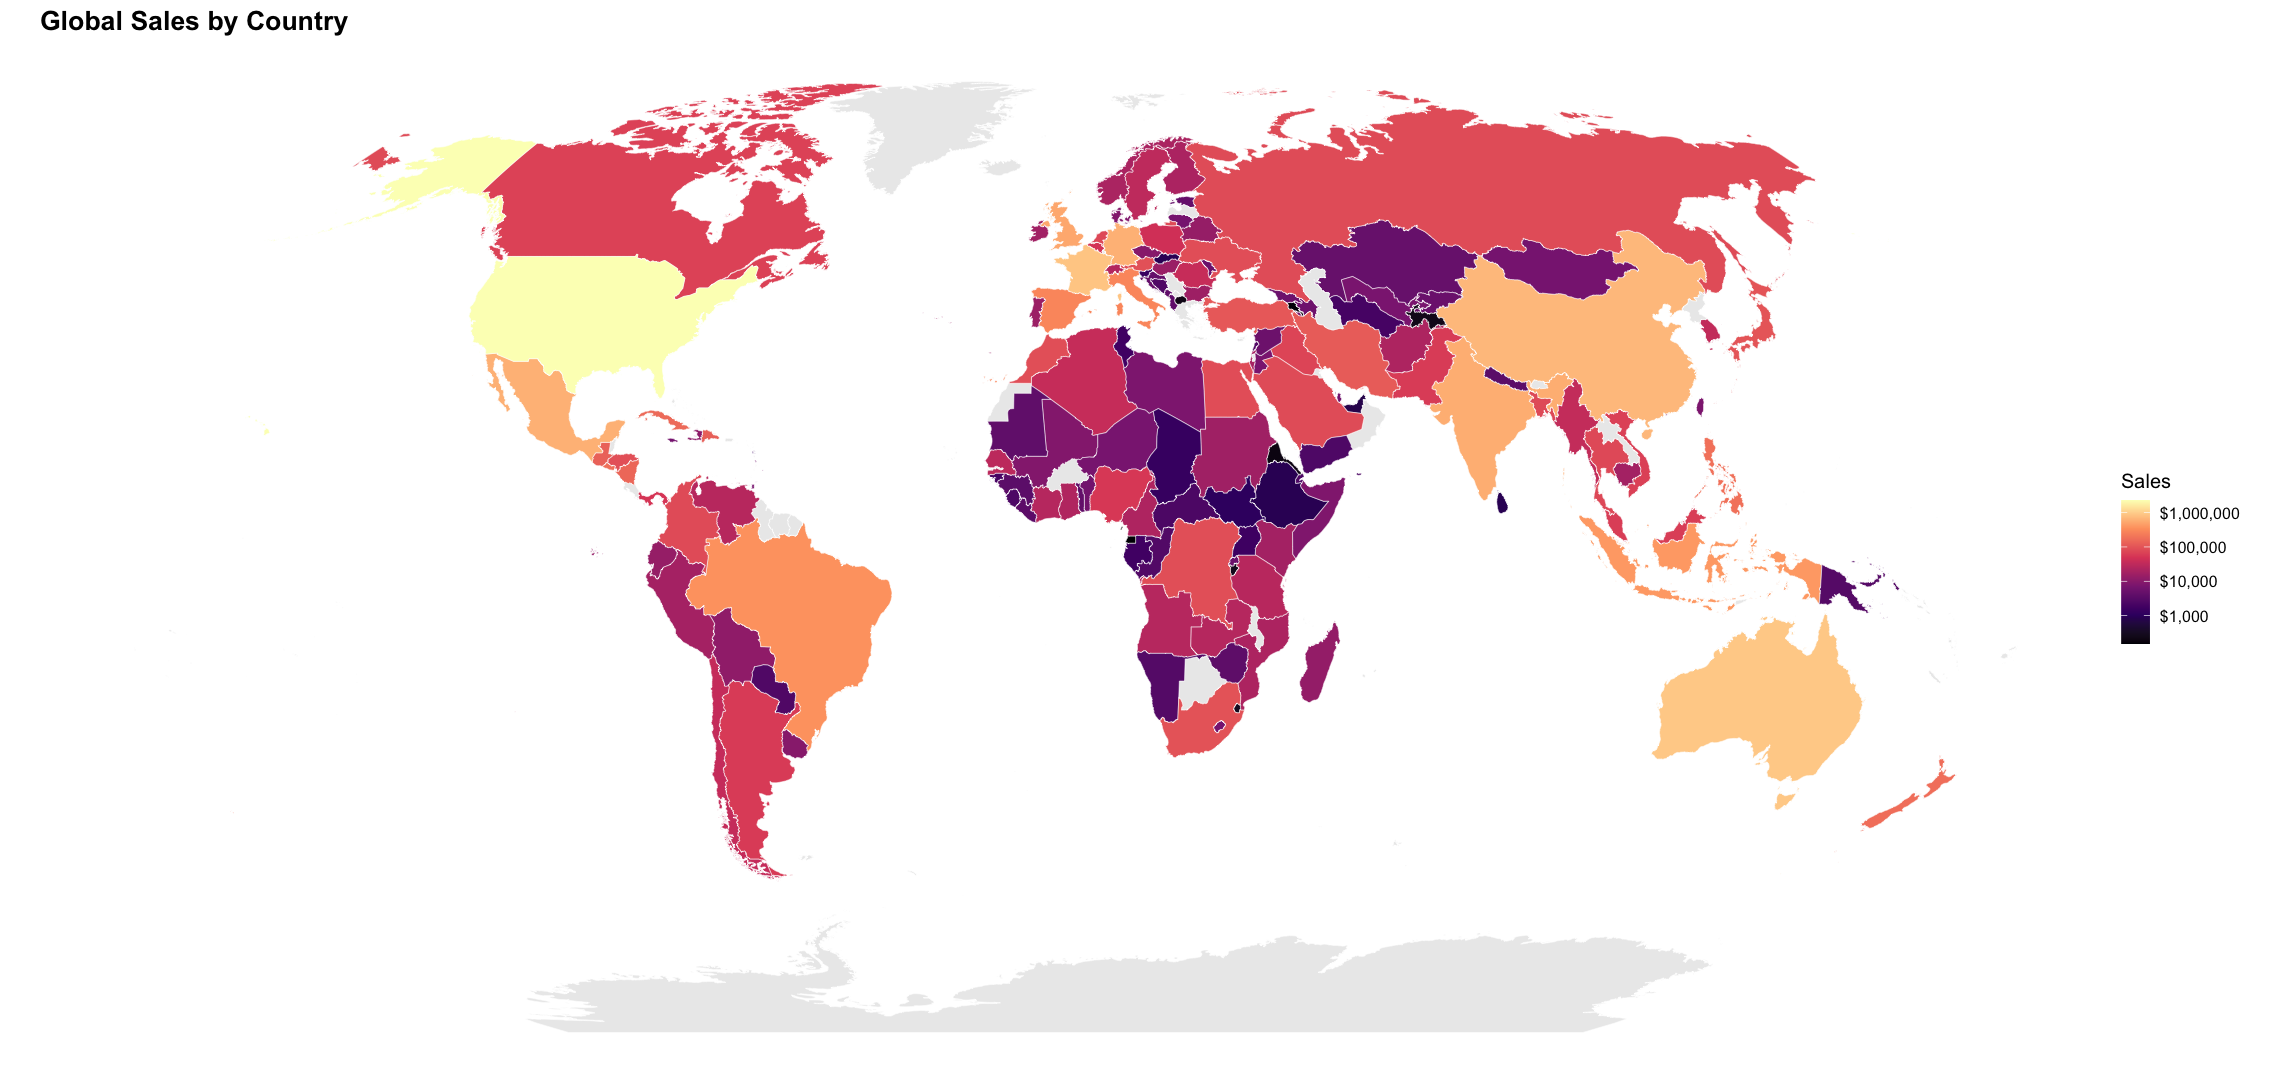

In [159]:
library(dplyr)
library(ggplot2)
library(scales)
library(countrycode)
library(geodata)
library(terra)
library(sf)

# 1) Aggregate sales to ISO3
country_sales <- orders |>
  mutate(
    iso3 = countrycode(country, "country.name", "iso3c",
      custom_match = c(
        "USA"="USA","U.S.A."="USA","United States of America"="USA",
        "UK"="GBR","Russia"="RUS","Vietnam"="VNM",
        "South Korea"="KOR","North Korea"="PRK",
        "Iran"="IRN","Venezuela"="VEN","Bolivia"="BOL",
        "Tanzania"="TZA","Congo"="COG","Democratic Republic of the Congo"="COD"
      )
    )
  ) |>
  filter(!is.na(iso3)) |>              
  group_by(iso3) |>
  summarise(total_sales = sum(sales, na.rm = TRUE), .groups = "drop")

# 2) Get world polygons
world_v  <- geodata::world(path = tempdir())
world_sf <- st_as_sf(world_v)

# world_sf has: GID_0 (ISO3), NAME_0, geometry
# 3) Join by ISO3 using GID_0
map_sf <- world_sf |>
  left_join(country_sales, by = c("GID_0" = "iso3"))

# 4) Project (helps avoid seam artifacts)
map_sf <- st_transform(map_sf, "+proj=robin")

# 5) Plot
options(repr.plot.width = 19, repr.plot.height = 9)
ggplot(map_sf) +
  geom_sf(aes(fill = total_sales), color = "white", linewidth = 0.15) +
  scale_fill_viridis_c(
    option = "magma",
    trans = "log10",
    labels = dollar_format(),
    na.value = "grey92"
  ) +
  labs(title = "Global Sales by Country", fill = "Sales") +
  theme_void(base_size = 12) +
  theme(
    plot.title = element_text(size = 16, face = "bold"),
    legend.position = "right"
  )